# Step 2 — Exploratory Data Analysis

Input: `DATA/interim/operations_clean.parquet`

A description of MIG's cement operation as the cleaned panel records it: 30
construction sites, 1,096 consecutive days, 32,880 site-days of planned pours,
actual consumption, deliveries, silo positions and weather.

The notebook works outward from the data. Sections 2-6 establish what is in the
panel and what the sites look like. Sections 7-14 describe how demand behaves —
its distribution, its movement over time, its variation across sites, its
response to weather, and the gap between what was planned and what was poured.
Sections 15-16 examine how the variables relate to one another and what actually
generates the target. Section 17 states what all of this implies for modelling,
and section 18 collects the conclusions.

| Section | Contents |
|---|---|
| 2 | Panel integrity and completeness |
| 3 | Data dictionary and when each column becomes knowable |
| 4 | Univariate descriptive statistics |
| 5 | The 30 sites: capacity, region, operating behaviour |
| 6 | What the three operating behaviours actually are |
| 7 | The demand distribution and the zero-consumption days |
| 8 | Trend and calendar seasonality |
| 9 | Autocorrelation |
| 10 | Where demand variation comes from |
| 11 | Cement types |
| 12 | Weather |
| 13 | Planned versus actual: censored demand |
| 14 | Inventory, deliveries and the operational baseline |
| 15 | Relationships between variables, and leakage |
| 16 | What generates the target |
| 17 | Grain, splits and modelling readiness |
| 18 | Findings and decisions |

Two results are worth knowing before reading: the operation is far more
deterministic than a demand-forecasting framing would suggest (section 16), and several
of the strongest-looking relationships in the data are consequences of the
target rather than predictors of it (section 15).

## 1 — Setup

In [1]:
import sys
from pathlib import Path

# This notebook lives in NOTEBOOKS/
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

print("Project root:", PROJECT_ROOT)

Project root: /sessions/elegant-kind-meitner/mnt/MIG_Cement_Demand_Forecasting


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

from mig_cement.config import settings

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

BEHAVIOUR_ORDER = ["aggressive", "chaotic", "conservative"]
BEHAVIOUR_COLOURS = {"aggressive": "#c44e52", "chaotic": "#dd8452", "conservative": "#4c72b0"}

# Established empirically in section 12; referenced from several places.
RAIN_STOPPAGE_MM = 15.0

FIG_DIR = PROJECT_ROOT / "REPORTS" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(name: str) -> None:
    # Saved so the figures can be reused in the written report.
    plt.savefig(FIG_DIR / f"02_{name}.png", dpi=130, bbox_inches="tight")


print("Imports successful. Figures ->", FIG_DIR)

Imports successful. Figures -> /sessions/elegant-kind-meitner/mnt/MIG_Cement_Demand_Forecasting/REPORTS/figures


## 2 — Panel integrity

The cleaning step established the grain and repaired the inventory ledger. This
section re-verifies those claims rather than assuming them, so that a future
extract which breaks the assumption fails here rather than silently downstream.

In [3]:
panel = pd.read_parquet(settings.interim_dir / "operations_clean.parquet")
panel["date"] = pd.to_datetime(panel["date"])
panel = panel.sort_values(["site_id", "date"]).reset_index(drop=True)

print(f"Shape: {panel.shape[0]:,} rows x {panel.shape[1]} columns")
panel.head()

Shape: 32,880 rows x 22 columns


,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity,region,behavior,received_tonnes,rejected_delivery_tonnes,served_tonnes,induced_shortfall,was_constrained,unmet_tonnes,silo_utilisation,cover_days,y
0,2022-01-01,SITE_001,CEM_II,43.180,34.540,52.560,45.830,63.850,3.400,-3.100,448,North,aggressive,45.830,0.000,34.540,0,1,8.640,0.143,1.522,34.540
1,2022-01-02,SITE_001,CEM_I,45.260,45.260,63.850,19.970,38.560,3.230,14.280,448,North,aggressive,19.970,0.000,45.260,0,0,0.000,0.086,1.411,45.260
2,2022-01-03,SITE_001,CEM_III,38.690,38.690,38.560,47.190,47.060,2.640,6.400,448,North,aggressive,47.190,0.000,38.690,0,0,0.000,0.105,0.997,38.690
3,2022-01-04,SITE_001,CEM_I,33.160,33.160,47.060,18.740,32.640,8.250,14.230,448,North,aggressive,18.740,0.000,33.160,0,0,0.000,0.073,1.419,33.160
4,2022-01-05,SITE_001,CEM_III,56.880,47.040,32.640,14.400,0.000,2.690,8.970,448,North,aggressive,14.400,0.000,47.040,0,1,9.840,0.000,0.694,47.040


In [4]:
n_sites = panel["site_id"].nunique()
n_days = panel["date"].nunique()

checks = {
    "Rows": f"{len(panel):,}",
    "Sites": n_sites,
    "Distinct dates": n_days,
    "Date range": f"{panel['date'].min():%Y-%m-%d} to {panel['date'].max():%Y-%m-%d}",
    "Calendar span (days)": (panel["date"].max() - panel["date"].min()).days + 1,
    "Panel complete (sites x days == rows)": n_sites * n_days == len(panel),
    "Duplicate (site, date) keys": int(panel.duplicated(["site_id", "date"]).sum()),
    "Site-days with more than one cement type": int((panel.groupby(["site_id", "date"]).size() > 1).sum()),
    "Rows per site (min / max)": f"{panel.groupby('site_id').size().min()} / {panel.groupby('site_id').size().max()}",
    "Regions": panel["region"].nunique(),
    "Cement types": panel["cement_type"].nunique(),
    "Operating behaviours": panel["behavior"].nunique(),
    "Missing values (all columns)": int(panel.isna().sum().sum()),
}
display(pd.DataFrame.from_dict(checks, orient="index", columns=["Value"]))

missing = panel.isna().sum()
print("Columns containing nulls:")
print((missing[missing > 0].to_string() if (missing > 0).any() else "  none"))

,Value
Rows,"32,880"
Sites,30
Distinct dates,1096
Date range,2022-01-01 to 2024-12-31
Calendar span (days),1096
Panel complete (sites x days == rows),True
"Duplicate (site, date) keys",0
Site-days with more than one cement type,0
Rows per site (min / max),1096 / 1096
Regions,4


Columns containing nulls:
cover_days    4003


The panel is a complete balanced grid: 30 sites × 1,096 consecutive days =
32,880 rows, exactly one cement type recorded per site-day, no duplicate keys and
no calendar gaps. Nothing needs reindexing or gap-filling.

The only nulls sit in `cover_days`, and they are not a data-quality issue — they
are informative in a way that matters. The next cell shows why.

In [5]:
# `cover_days` is defined during cleaning as opening inventory / consumption,
# left null where consumption is zero. Its missingness therefore encodes the target.
is_zero = panel["consumed_tonnes"] == 0
is_null = panel["cover_days"].isna()

print(f"Rows where cover_days is null : {is_null.sum():,}")
print(f"Rows where consumption is zero: {is_zero.sum():,}")
print(f"The two sets are identical    : {(is_null == is_zero).all()}")
print()
print("So cover_days.isna() identifies a zero-demand day with perfect accuracy.")
print("It describes the day's outcome; it does not anticipate it. Section 15")
print("returns to this as the clearest leakage risk in the dataset.")

Rows where cover_days is null : 4,003
Rows where consumption is zero: 4,003
The two sets are identical    : True

So cover_days.isna() identifies a zero-demand day with perfect accuracy.
It describes the day's outcome; it does not anticipate it. Section 15
returns to this as the clearest leakage risk in the dataset.


## 3 — Data dictionary and forecast-time availability

The panel carries 22 columns: 11 from the source database and 11 added during
cleaning. Beyond dtype and cardinality, the useful thing to record
about each one is *when its value becomes knowable*, because that determines
whether it can inform a forecast or only describe an outcome.

- **static** — a fixed site attribute
- **scheduled** — set administratively in advance
- **forecastable exogenous** — unknown, but a forecast is obtainable
- **state** — known at the start of day *t*; beyond a one-day horizon it must be
  projected, which is what an inventory simulation would do
- **outcome** — realised during day *t*

In [6]:
AVAILABILITY = {
    "site_id": "static",
    "region": "static",
    "behavior": "static",
    "silo_capacity": "static",
    "cement_type": "scheduled",
    "planned_pour_tonnes": "scheduled",
    "rain_mm": "forecastable exogenous",
    "avg_temp_c": "forecastable exogenous",
    "opening_inventory_tonnes": "state (project beyond h=1)",
    "deliveries_tonnes": "state (scheduled deliveries)",
    "consumed_tonnes": "OUTCOME (target)",
    "y": "OUTCOME (target, alias)",
    "served_tonnes": "OUTCOME (post-repair consumption)",
    "received_tonnes": "OUTCOME",
    "rejected_delivery_tonnes": "OUTCOME",
    "induced_shortfall": "OUTCOME",
    "was_constrained": "OUTCOME",
    "unmet_tonnes": "OUTCOME",
    "closing_inventory_tonnes": "OUTCOME",
    "silo_utilisation": "OUTCOME",
    "cover_days": "OUTCOME (also identifies a zero target)",
}
DESCRIPTION = {
    "site_id": "Construction site identifier",
    "region": "North / South / East / West",
    "behavior": "Operating archetype: aggressive / chaotic / conservative",
    "silo_capacity": "Site silo capacity, tonnes",
    "cement_type": "Grade poured that day: CEM_I / CEM_II / CEM_III",
    "planned_pour_tonnes": "Concrete pour scheduled for the day, in cement tonnes",
    "rain_mm": "Daily rainfall at the site",
    "avg_temp_c": "Daily mean temperature",
    "opening_inventory_tonnes": "Silo contents at start of day (repaired ledger)",
    "deliveries_tonnes": "Cement offered for delivery that day",
    "consumed_tonnes": "Cement actually poured, as recorded",
    "y": "Modelling target, currently a copy of consumed_tonnes",
    "served_tonnes": "Consumption recomputed against the repaired ledger",
    "received_tonnes": "Delivery accepted into the silo",
    "rejected_delivery_tonnes": "Delivery turned away for lack of headroom",
    "induced_shortfall": "Ledger repair forced a shortfall on this row",
    "was_constrained": "consumed < planned",
    "unmet_tonnes": "planned - consumed, floored at zero",
    "closing_inventory_tonnes": "Silo contents at end of day",
    "silo_utilisation": "closing inventory / capacity",
    "cover_days": "opening inventory / consumption, in days",
}

dictionary = pd.DataFrame({
    "description": pd.Series(DESCRIPTION),
    "availability": pd.Series(AVAILABILITY),
}).reindex(panel.columns)
dictionary["dtype"] = panel.dtypes.astype(str)
dictionary["n_unique"] = panel.nunique()
dictionary["n_null"] = panel.isna().sum()
display(dictionary)

SAFE_COLS = [c for c, a in AVAILABILITY.items() if not a.startswith("OUTCOME")]
OUTCOME_COLS = [c for c, a in AVAILABILITY.items() if a.startswith("OUTCOME")]
print(f"Knowable at forecast time: {len(SAFE_COLS)}   Outcomes: {len(OUTCOME_COLS)}")

,description,availability,dtype,n_unique,n_null
date,NaN,NaN,datetime64[ns],1096,0
site_id,Construction site identifier,static,object,30,0
cement_type,Grade poured that day: CEM_I / CEM_II / CEM_III,scheduled,object,3,0
planned_pour_tonnes,"Concrete pour scheduled for the day, in cement...",scheduled,float64,5753,0
consumed_tonnes,"Cement actually poured, as recorded",OUTCOME (target),float64,5810,0
opening_inventory_tonnes,Silo contents at start of day (repaired ledger),state (project beyond h=1),float64,20979,0
deliveries_tonnes,Cement offered for delivery that day,state (scheduled deliveries),float64,4002,0
closing_inventory_tonnes,Silo contents at end of day,OUTCOME,float64,20968,0
rain_mm,Daily rainfall at the site,forecastable exogenous,float64,2389,0
avg_temp_c,Daily mean temperature,forecastable exogenous,float64,3526,0


Knowable at forecast time: 10   Outcomes: 11


## 4 — Univariate descriptive statistics

In [7]:
numeric_summary = (
    panel[[
        "planned_pour_tonnes", "consumed_tonnes", "served_tonnes", "unmet_tonnes",
        "deliveries_tonnes", "received_tonnes", "rejected_delivery_tonnes",
        "opening_inventory_tonnes", "closing_inventory_tonnes",
        "silo_capacity", "silo_utilisation", "cover_days",
        "rain_mm", "avg_temp_c",
    ]]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .T
    .round(2)
)
numeric_summary["zeros %"] = [
    100 * (panel[c] == 0).mean() for c in numeric_summary.index
]
display(numeric_summary)

,count,mean,std,min,5%,25%,50%,75%,95%,max,zeros %
planned_pour_tonnes,"32,880.000",30.700,19.490,0.000,0.000,12.830,33.460,47.610,58.860,69.980,9.103
consumed_tonnes,"32,880.000",23.720,16.850,0.000,0.000,10.710,19.720,36.490,53.740,69.970,12.175
served_tonnes,"32,880.000",23.600,16.740,0.000,0.000,10.690,19.690,36.330,53.340,69.970,12.223
unmet_tonnes,"32,880.000",6.980,12.280,0.000,0.000,0.000,0.000,9.490,35.170,69.620,60.307
deliveries_tonnes,"32,880.000",29.290,12.330,0.000,11.040,19.300,29.490,39.750,48.010,50.000,2.457
received_tonnes,"32,880.000",23.670,13.520,0.000,5.340,12.820,20.520,35.250,47.010,50.000,3.884
rejected_delivery_tonnes,"32,880.000",5.620,10.820,0.000,0.000,0.000,0.000,5.210,31.920,49.940,71.694
opening_inventory_tonnes,"32,880.000",123.610,150.580,0.000,0.000,0.470,44.850,256.080,453.080,487.000,4.167
closing_inventory_tonnes,"32,880.000",123.680,150.630,0.000,0.000,0.440,44.830,256.160,453.100,487.000,4.173
silo_capacity,"32,880.000",317.530,112.810,120.000,152.000,230.000,314.000,437.000,487.000,487.000,0.000


In [8]:
categorical = pd.concat([
    panel[c].value_counts().rename("rows").to_frame().assign(
        column=c, share=lambda d: (d["rows"] / len(panel)).round(4)
    ).reset_index(names="value")
    for c in ["region", "behavior", "cement_type"]
])
display(categorical.set_index(["column", "value"])[["rows", "share"]])

rows  share
column      value                     
region      East          13152  0.400
            South         12056  0.367
            West           4384  0.133
            North          3288  0.100
behavior    aggressive    15344  0.467
            conservative   9864  0.300
            chaotic        7672  0.233
cement_type CEM_II        11097  0.338
            CEM_I         10913  0.332
            CEM_III       10870  0.331

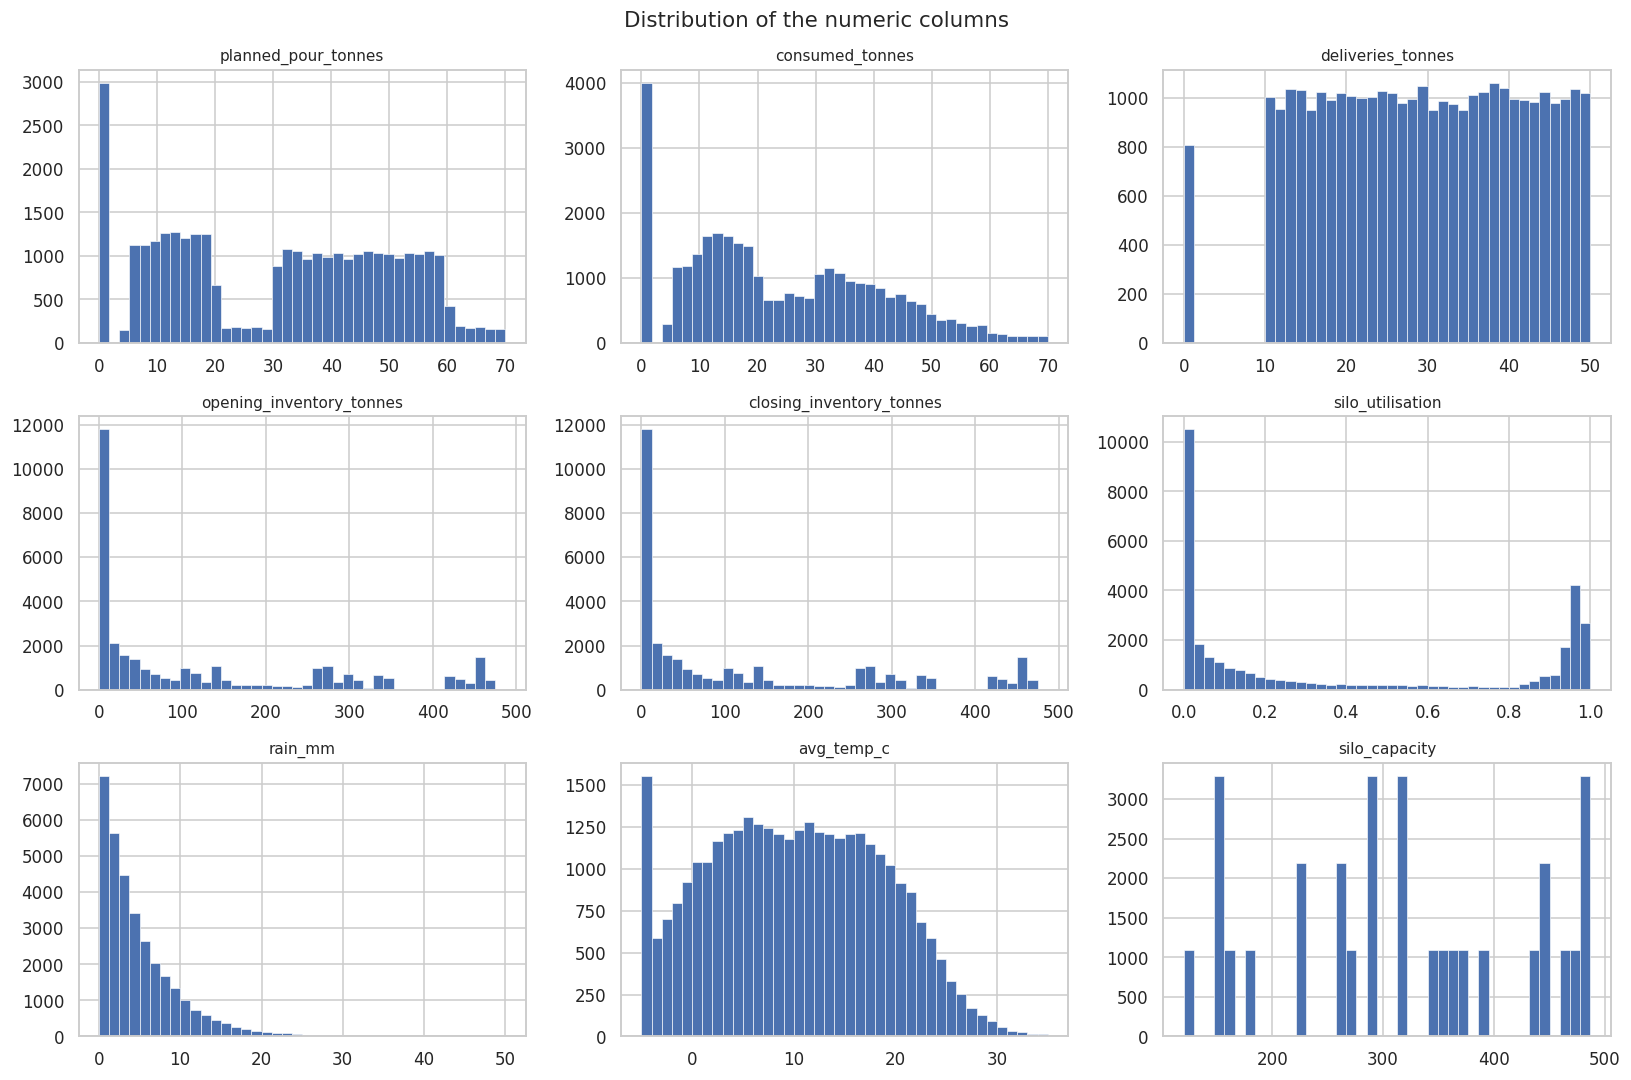

In [9]:
numeric_cols = [
    "planned_pour_tonnes", "consumed_tonnes", "deliveries_tonnes",
    "opening_inventory_tonnes", "closing_inventory_tonnes", "silo_utilisation",
    "rain_mm", "avg_temp_c", "silo_capacity",
]
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.ravel(), numeric_cols):
    ax.hist(panel[col].dropna(), bins=40, edgecolor="white", linewidth=0.4)
    ax.set_title(col, fontsize=10)
plt.suptitle("Distribution of the numeric columns", fontsize=14)
plt.tight_layout()
save_fig("numeric_distributions")
plt.show()

Several shapes here are worth naming, because they say something about how the
operation runs rather than merely how the data is distributed.

- **`deliveries_tonnes` is close to uniform on [10, 50]** — mean 30.03, standard
  deviation 11.56, quartiles at 20 / 30 / 40. A uniform draw on that interval has
  mean 30 and standard deviation 11.55. Deliveries are not sized to need.
- **`rain_mm` is a smooth right-skewed distribution** with a long thin tail; only
  0.08% of days are completely dry, and the 99th percentile is 23.3 mm.
- **`avg_temp_c` spans −5 to 35 °C** with a broad, near-symmetric spread.
- **`silo_utilisation` is strongly bimodal**, piling up at both 0 and 1. Silos are
  either nearly empty or completely full, rarely in between. Section 6 explains
  which sites sit at which end.
- **`planned_pour_tonnes` is multi-modal**, which is the three operating
  behaviours superimposed rather than one underlying distribution.

## 5 — The 30 sites

Every site attribute in the panel is fixed for the whole three years: region,
silo capacity and operating behaviour never change. This section describes the
cross-section those attributes define.

In [10]:
sites = panel.groupby("site_id").agg(
    region=("region", "first"),
    behavior=("behavior", "first"),
    silo_capacity=("silo_capacity", "first"),
    mean_planned=("planned_pour_tonnes", "mean"),
    mean_consumed=("consumed_tonnes", "mean"),
    sd_consumed=("consumed_tonnes", "std"),
    pct_constrained=("was_constrained", lambda s: 100 * s.mean()),
    mean_utilisation=("silo_utilisation", lambda s: 100 * s.mean()),
)
sites["cv_consumed"] = (sites["sd_consumed"] / sites["mean_consumed"]).round(3)
sites["fill_rate_pct"] = (100 * sites["mean_consumed"] / sites["mean_planned"]).round(1)
sites["silo_cover_days"] = (sites["silo_capacity"] / sites["mean_planned"]).round(1)

display(sites.sort_values("mean_consumed", ascending=False).round(2))

,region,behavior,silo_capacity,mean_planned,mean_consumed,sd_consumed,pct_constrained,mean_utilisation,cv_consumed,fill_rate_pct,silo_cover_days
site_id,,,,,,,,,,,
SITE_025,South,aggressive,261,42.720,30.660,15.180,63.690,5.050,0.500,71.800,6.100
SITE_010,West,aggressive,158,42.810,30.640,14.890,63.500,8.350,0.490,71.600,3.700
SITE_018,East,aggressive,152,42.730,30.430,14.280,63.780,9.170,0.470,71.200,3.600
SITE_001,North,aggressive,448,42.580,30.160,14.900,64.230,3.160,0.490,70.800,10.500
SITE_021,East,aggressive,180,43.220,30.120,14.500,66.610,6.430,0.480,69.700,4.200
SITE_005,South,aggressive,230,42.320,30.050,14.610,64.690,5.340,0.490,71.000,5.400
SITE_022,South,aggressive,487,43.200,30.050,14.390,66.330,2.740,0.480,69.600,11.300
SITE_008,West,aggressive,260,43.010,29.830,14.460,67.340,4.720,0.480,69.300,6.000
SITE_007,East,aggressive,485,43.020,29.750,14.520,64.690,2.690,0.490,69.200,11.300


In [11]:
print("Sites per region and behaviour")
display(pd.crosstab(sites["region"], sites["behavior"], margins=True, margins_name="All"))

print("\nSilo capacity across the 30 sites")
display(sites["silo_capacity"].describe().round(1).to_frame().T)

print(f"Site-level correlation between silo capacity and mean planned pour: "
      f"{sites['silo_capacity'].corr(sites['mean_planned']):+.3f}")
print("Capacity was assigned independently of throughput — the silos are not")
print("sized to the work the sites do. Section 6 shows what that produces.")

Sites per region and behaviour


behavior,aggressive,chaotic,conservative,All
region,,,,
East,5,4,3,12
North,1,0,2,3
South,6,2,3,11
West,2,1,1,4
All,14,7,9,30



Silo capacity across the 30 sites


,count,mean,std,min,25%,50%,75%,max
silo_capacity,30.000,317.500,114.700,120.000,237.500,314.000,426.500,487.000


Site-level correlation between silo capacity and mean planned pour: -0.048
Capacity was assigned independently of throughput — the silos are not
sized to the work the sites do. Section 6 shows what that produces.


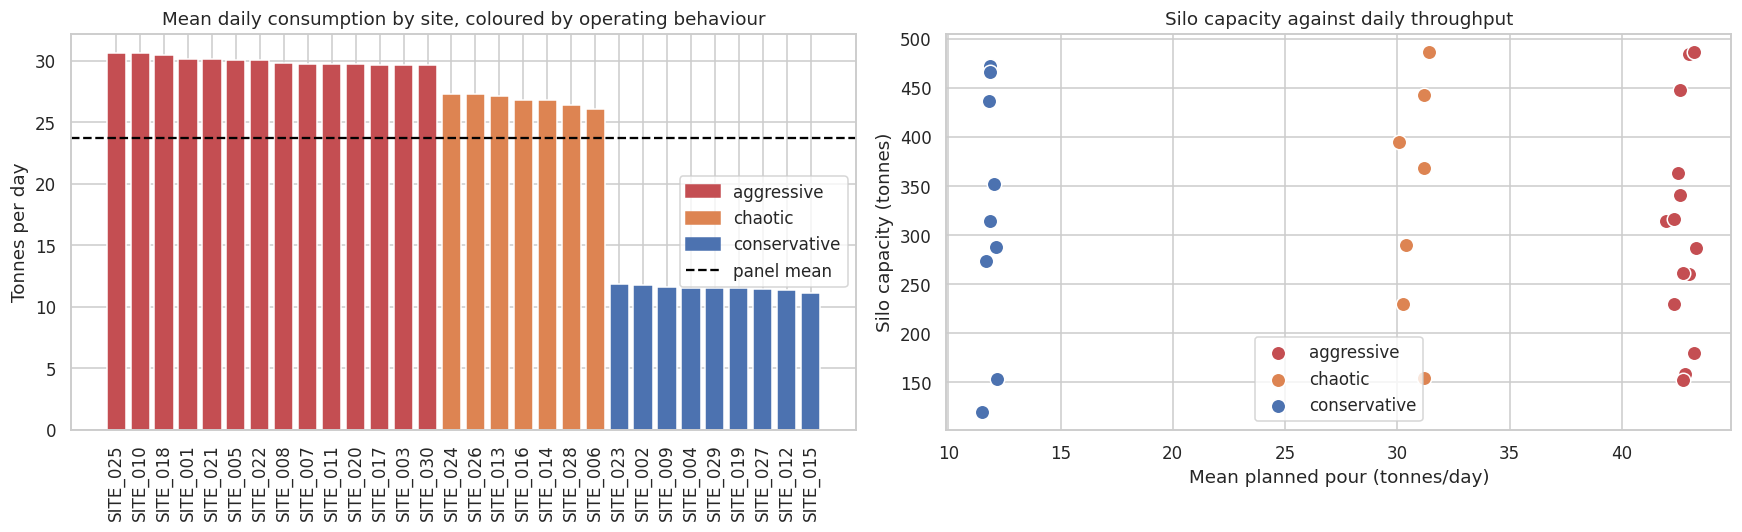

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ordered = sites.sort_values("mean_consumed", ascending=False)
axes[0].bar(ordered.index, ordered["mean_consumed"],
            color=[BEHAVIOUR_COLOURS[b] for b in ordered["behavior"]])
axes[0].axhline(panel["consumed_tonnes"].mean(), color="black", linestyle="--",
                label="panel mean")
axes[0].set_title("Mean daily consumption by site, coloured by operating behaviour")
axes[0].set_ylabel("Tonnes per day")
axes[0].tick_params(axis="x", rotation=90)
axes[0].legend(
    [plt.Rectangle((0, 0), 1, 1, color=BEHAVIOUR_COLOURS[b]) for b in BEHAVIOUR_ORDER]
    + [plt.Line2D([0], [0], color="black", linestyle="--")],
    BEHAVIOUR_ORDER + ["panel mean"],
)

for b in BEHAVIOUR_ORDER:
    sub = sites[sites["behavior"] == b]
    axes[1].scatter(sub["mean_planned"], sub["silo_capacity"], s=90,
                    color=BEHAVIOUR_COLOURS[b], label=b, edgecolor="white")
axes[1].set_xlabel("Mean planned pour (tonnes/day)")
axes[1].set_ylabel("Silo capacity (tonnes)")
axes[1].set_title("Silo capacity against daily throughput")
axes[1].legend()

plt.tight_layout()
save_fig("site_cross_section")
plt.show()

The site table separates cleanly into three tight clusters with almost no overlap:
mean daily consumption is ~30 t for every aggressive site, ~26.8 t for every
chaotic site and ~11.5 t for every conservative site. Within a cluster the sites
are near-identical.

The scatter on the right is the important one. Silo capacity ranges from 120 to
487 t and is **uncorrelated with throughput** (r = −0.05) — the three behaviour
groups are stacked vertically at three different pour rates across the same
capacity range. Whatever determines how much a site pours, it had nothing to do
with how much cement it can store.

## 6 — What the three operating behaviours are

`behavior` is the most informative site attribute in the panel, and its meaning
is not obvious from the label. The three groups are not distinguished by how they
order cement — they order almost identically — but by how much work they schedule
against that supply.

In [13]:
behaviour_profile = panel.groupby("behavior").apply(
    lambda g: pd.Series({
        "sites": g["site_id"].nunique(),
        "days with a delivery %": 100 * (g["deliveries_tonnes"] > 0).mean(),
        "mean delivery offered (t)": g.loc[g["deliveries_tonnes"] > 0, "deliveries_tonnes"].mean(),
        "supply offered (t/day)": g["deliveries_tonnes"].mean(),
        "demand planned (t/day)": g["planned_pour_tonnes"].mean(),
        "supply : demand": g["deliveries_tonnes"].sum() / g["planned_pour_tonnes"].sum(),
        "mean silo capacity (t)": g["silo_capacity"].mean(),
    }),
    include_groups=False,
).reindex(BEHAVIOUR_ORDER)
behaviour_profile["silo cover at plan (days)"] = (
    behaviour_profile["mean silo capacity (t)"] / behaviour_profile["demand planned (t/day)"]
)
display(behaviour_profile.round(2))

,sites,days with a delivery %,mean delivery offered (t),supply offered (t/day),demand planned (t/day),supply : demand,mean silo capacity (t),silo cover at plan (days)
behavior,,,,,,,,
aggressive,14.000,100.000,29.980,29.980,42.740,0.700,305.860,7.160
chaotic,7.000,89.470,30.260,27.070,30.820,0.880,338.290,10.980
conservative,9.000,100.000,29.960,29.960,11.880,2.520,319.560,26.900


In [14]:
behaviour_outcomes = panel.groupby("behavior").apply(
    lambda g: pd.Series({
        "empty-silo days %": 100 * (g["opening_inventory_tonnes"] < 1).mean(),
        "mean silo utilisation %": 100 * g["silo_utilisation"].mean(),
        "rows where pour was cut short %": 100 * g["was_constrained"].mean(),
        "demand fill rate %": 100 * g["consumed_tonnes"].sum() / g["planned_pour_tonnes"].sum(),
        "deliveries rejected %": 100 * g["rejected_delivery_tonnes"].sum() / g["deliveries_tonnes"].sum(),
        "unmet demand (t)": g["unmet_tonnes"].sum(),
    }),
    include_groups=False,
).reindex(BEHAVIOUR_ORDER)
display(behaviour_outcomes.round(2))

print("Variability of the schedule itself:")
display(panel.groupby("behavior").apply(
    lambda g: pd.Series({
        "planned pour CV": g["planned_pour_tonnes"].std() / g["planned_pour_tonnes"].mean(),
        "days with no pour scheduled %": 100 * (g["planned_pour_tonnes"] == 0).mean(),
    }), include_groups=False,
).reindex(BEHAVIOUR_ORDER).round(3))

,empty-silo days %,mean silo utilisation %,rows where pour was cut short %,demand fill rate %,deliveries rejected %,unmet demand (t)
behavior,,,,,,
aggressive,48.820,4.990,65.010,70.220,0.010,"195,289.190"
chaotic,11.210,33.660,21.770,87.050,2.600,"30,628.060"
conservative,0.000,94.980,14.250,97.030,60.730,"3,476.110"


Variability of the schedule itself:


,planned pour CV,days with no pour scheduled %
behavior,,
aggressive,0.303,4.966
chaotic,0.738,23.162
conservative,0.420,4.603


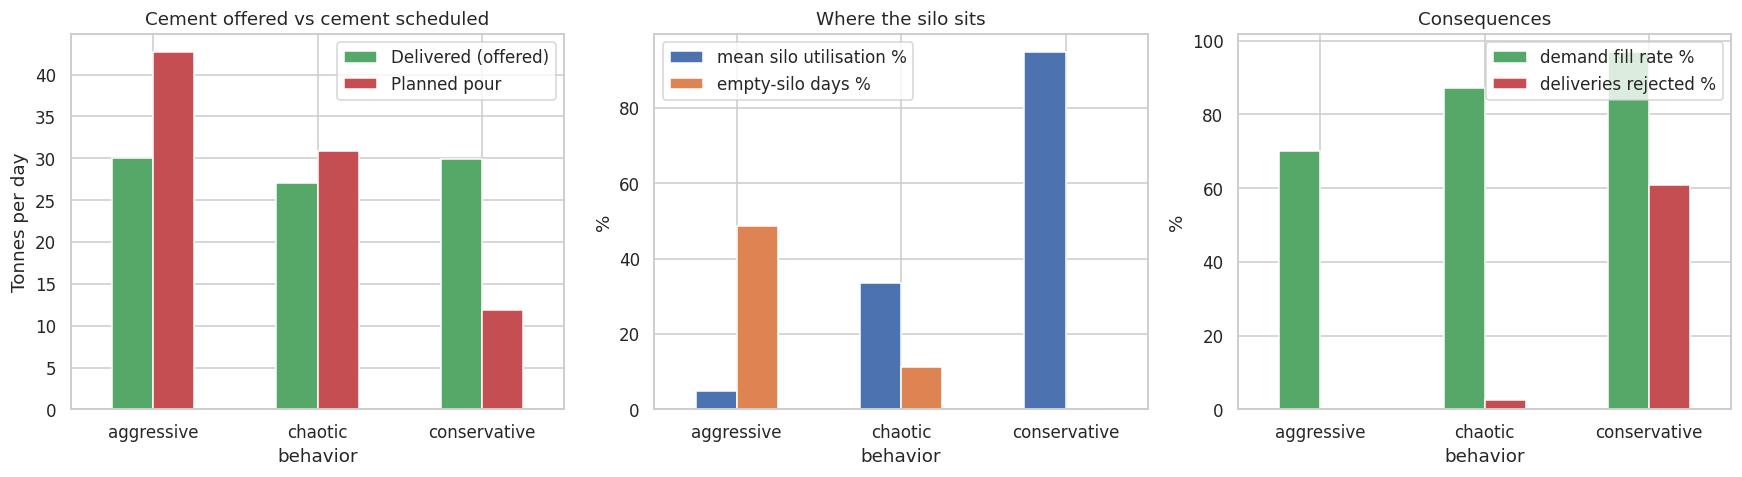

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

behaviour_profile[["supply offered (t/day)", "demand planned (t/day)"]].plot(
    kind="bar", ax=axes[0], color=["#55a868", "#c44e52"])
axes[0].set_title("Cement offered vs cement scheduled")
axes[0].set_ylabel("Tonnes per day")
axes[0].legend(["Delivered (offered)", "Planned pour"])

behaviour_outcomes[["mean silo utilisation %", "empty-silo days %"]].plot(
    kind="bar", ax=axes[1], color=["#4c72b0", "#dd8452"])
axes[1].set_title("Where the silo sits")
axes[1].set_ylabel("%")

behaviour_outcomes[["demand fill rate %", "deliveries rejected %"]].plot(
    kind="bar", ax=axes[2], color=["#55a868", "#c44e52"])
axes[2].set_title("Consequences")
axes[2].set_ylabel("%")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
save_fig("behaviour_profile")
plt.show()

**The delivery process is effectively identical for all three groups.** Every
site is offered around 30 t/day, in individual loads averaging 30 t, on
essentially every day. What separates the groups is how much work they schedule
against that constant supply:

| | aggressive | chaotic | conservative |
|---|---|---|---|
| sites | 14 | 7 | 9 |
| planned pour (t/day) | **42.7** | 30.8 | **11.9** |
| cement offered (t/day) | 30.0 | 27.1 | 30.0 |
| **supply : demand** | **0.70** | 0.88 | **2.52** |
| silo capacity (mean t) | 306 | 338 | 320 |
| silo cover at plan (days) | 7.2 | 11.0 | 26.9 |

and the outcomes follow directly:

| | aggressive | chaotic | conservative |
|---|---|---|---|
| empty-silo days | **48.8%** | 11.2% | 0.0% |
| mean silo utilisation | 5.0% | 33.7% | **95.0%** |
| pours cut short | 65.0% | 21.8% | 14.3% |
| demand fill rate | 70.2% | 87.1% | 97.0% |
| deliveries turned away | 0.01% | 2.6% | **60.7%** |

**Aggressive** sites schedule 43% more concrete than arrives. Their silos are
empty on nearly half of all days and 30% of planned work never happens; these 14
sites account for 195,289 of the 229,393 unmet tonnes in the panel.

**Conservative** sites receive two and a half times what they pour. Their silos
sit permanently full, so 61% of arriving cement has nowhere to go. They almost
never miss a pour, but they are storing cement they will not use — this is the
group whose recorded inventory reached 10,061 t in a ~320 t silo and forced the
ledger repair during cleaning.

**Chaotic** describes irregularity, not level. It is the only group whose
deliveries skip days (89.5% versus 100%), it has by far the most erratic schedule
(planned-pour CV 0.74 against 0.30 and 0.42), and 23.2% of its days have no pour
scheduled at all against roughly 5% elsewhere. Supply and demand balance on
average; they just do not line up day to day.

Two observations follow. First, the label is somewhat misleading — it reads as a
description of purchasing discipline, but purchasing is constant; it is really a
throughput-to-storage ratio, and is worth renaming before it reaches a dashboard.
Second, **no site is responding to its inventory position at all.** Cement
arrives at a flat ~30 t/day regardless of stock level or upcoming pours. There is
no reorder policy in this data at all. That is the opportunity — but it also
means the status quo being improved on is *blind* ordering rather than reactive
ordering, which is a weaker baseline than it first appears and should be
described as such when any improvement is reported.

## 7 — The demand distribution

`consumed_tonnes` averages 23.7 t per site-day. The distribution has two distinct
parts: a spike at zero covering 12.2% of rows, and a broad near-symmetric body
covering the rest. Both parts are worth describing separately, because they turn
out to have different explanations.

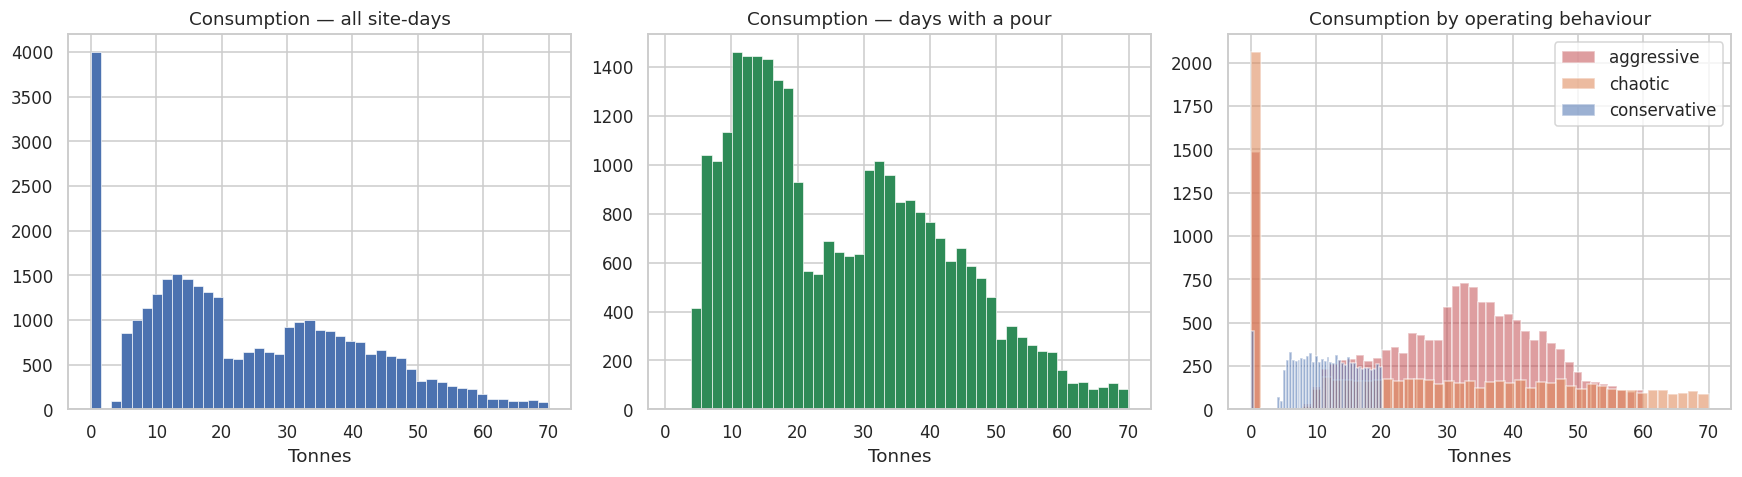

All rows      mean  23.72 t   median  19.72 t
Pour days     mean  27.01 t   median  24.64 t
Pour days     skew +0.524  -> near-symmetric, no log transform warranted
Zero days     4,003 rows (12.17%)


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(panel["consumed_tonnes"], bins=45, edgecolor="white", linewidth=0.4)
axes[0].set_title("Consumption — all site-days")
axes[0].set_xlabel("Tonnes")

nonzero = panel.loc[panel["consumed_tonnes"] > 0, "consumed_tonnes"]
axes[1].hist(nonzero, bins=45, color="seagreen", edgecolor="white", linewidth=0.4)
axes[1].set_title("Consumption — days with a pour")
axes[1].set_xlabel("Tonnes")

for b in BEHAVIOUR_ORDER:
    sub = panel.loc[panel["behavior"] == b, "consumed_tonnes"]
    axes[2].hist(sub, bins=45, alpha=0.55, label=b, color=BEHAVIOUR_COLOURS[b])
axes[2].set_title("Consumption by operating behaviour")
axes[2].set_xlabel("Tonnes")
axes[2].legend()

plt.tight_layout()
save_fig("demand_distribution")
plt.show()

print(f"All rows      mean {panel['consumed_tonnes'].mean():6.2f} t   median {panel['consumed_tonnes'].median():6.2f} t")
print(f"Pour days     mean {nonzero.mean():6.2f} t   median {nonzero.median():6.2f} t")
print(f"Pour days     skew {nonzero.skew():+.3f}  -> near-symmetric, no log transform warranted")
print(f"Zero days     {(panel['consumed_tonnes'] == 0).sum():,} rows ({(panel['consumed_tonnes'] == 0).mean():.2%})")

The middle panel is the useful one: once the zeros are removed, consumption is
almost symmetric (skew +0.52, mean 27.0 t against median 24.6 t). There is no
heavy right tail and no case for a log or Box-Cox transform — an unusual result
for demand data, and one that simplifies the modelling.

The right-hand panel shows the three behaviour groups producing three separate
humps. The apparent multi-modality of the overall distribution is composition,
not a property of any individual site.

The zeros deserve their own explanation.

In [17]:
zeros = panel["consumed_tonnes"] == 0

no_pour = panel["planned_pour_tonnes"] == 0
print("Cause 1 — no pour was scheduled")
print(f"  rows with planned_pour == 0         : {no_pour.sum():,} ({no_pour.mean():.2%} of panel)")
print(f"  of those, consumption is also zero  : {(panel.loc[no_pour, 'consumed_tonnes'] == 0).mean():.2%}")
print()

remaining = panel[zeros & ~no_pour]
rained_off = remaining["rain_mm"] > RAIN_STOPPAGE_MM
stocked_out = remaining["opening_inventory_tonnes"] < 1.0
print(f"Zero-consumption days despite a scheduled pour: {len(remaining):,}")
print(f"  rainfall above {RAIN_STOPPAGE_MM:g} mm                 : {rained_off.mean():.1%}")
print(f"  opening silo below 1 t                : {stocked_out.mean():.1%}")
print(f"  at least one of the two               : {(rained_off | stocked_out).mean():.1%}")
print(f"  neither                               : {(~(rained_off | stocked_out)).sum()} row(s)")

Cause 1 — no pour was scheduled
  rows with planned_pour == 0         : 2,993 (9.10% of panel)
  of those, consumption is also zero  : 100.00%

Zero-consumption days despite a scheduled pour: 1,010
  rainfall above 15 mm                 : 95.3%
  opening silo below 1 t                : 40.8%
  at least one of the two               : 99.9%
  neither                               : 1 row(s)


,rows,% of zero days,% of panel
No pour scheduled,2993,74.770,9.100
Rained off,963,24.060,2.930
Silo empty,46,1.150,0.140
Unexplained,1,0.020,0.000


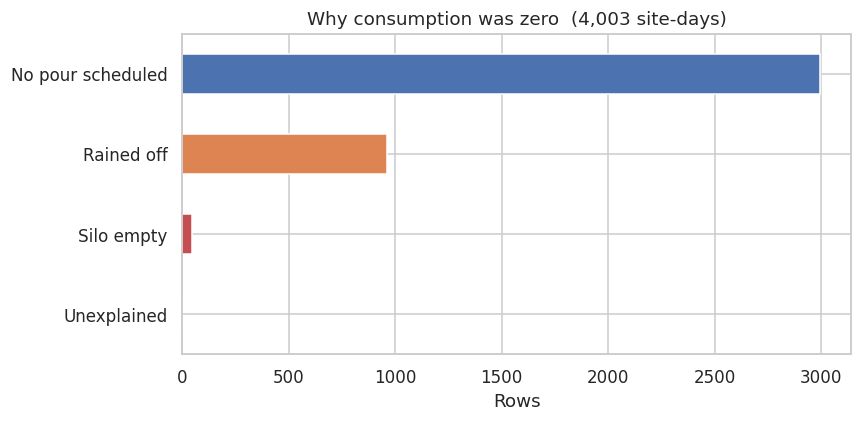

In [18]:
def classify_zero(row):
    if row["planned_pour_tonnes"] == 0:
        return "No pour scheduled"
    if row["rain_mm"] > RAIN_STOPPAGE_MM:
        return "Rained off"
    if row["opening_inventory_tonnes"] < 1.0:
        return "Silo empty"
    return "Unexplained"

taxonomy = panel[zeros].apply(classify_zero, axis=1).value_counts()
display(pd.DataFrame({
    "rows": taxonomy,
    "% of zero days": (100 * taxonomy / taxonomy.sum()).round(2),
    "% of panel": (100 * taxonomy / len(panel)).round(2),
}))

plt.figure(figsize=(8, 4))
taxonomy.sort_values().plot(kind="barh",
                            color=["#8172b3", "#c44e52", "#dd8452", "#4c72b0"])
plt.title(f"Why consumption was zero  ({zeros.sum():,} site-days)")
plt.xlabel("Rows")
plt.tight_layout()
save_fig("zero_taxonomy")
plt.show()

**The zeros are structural.** Of 4,003 zero-consumption site-days, 4,002 are
fully accounted for by three causes:

| cause | rows | share of zero days |
|---|---|---|
| No pour scheduled | 2,993 | 74.8% |
| Rained off | 963 | 24.1% |
| Silo empty | 46 | 1.1% |
| Unexplained | **1** | 0.0% |

A zero planned pour implies zero consumption on **100%** of rows — 2,993 for
2,993. There is no noise in that relationship at all.

This changes how the zeros should be treated. They are not missing data or
measurement noise to be smoothed over; they are three identifiable operational
states, all of which are knowable or forecastable in advance. A two-stage
(hurdle) specification — first whether a pour happens, then how much — matches
the data's own structure, and the first stage is closer to a lookup than a
learned model. It is also the concrete reason MAPE fails as a headline metric:
it is undefined on 12.2% of rows by construction.

## 8 — Trend and calendar seasonality

Three full years of daily data, aggregated to national totals. The question is
whether demand follows the calendar in any way a forecast could use.

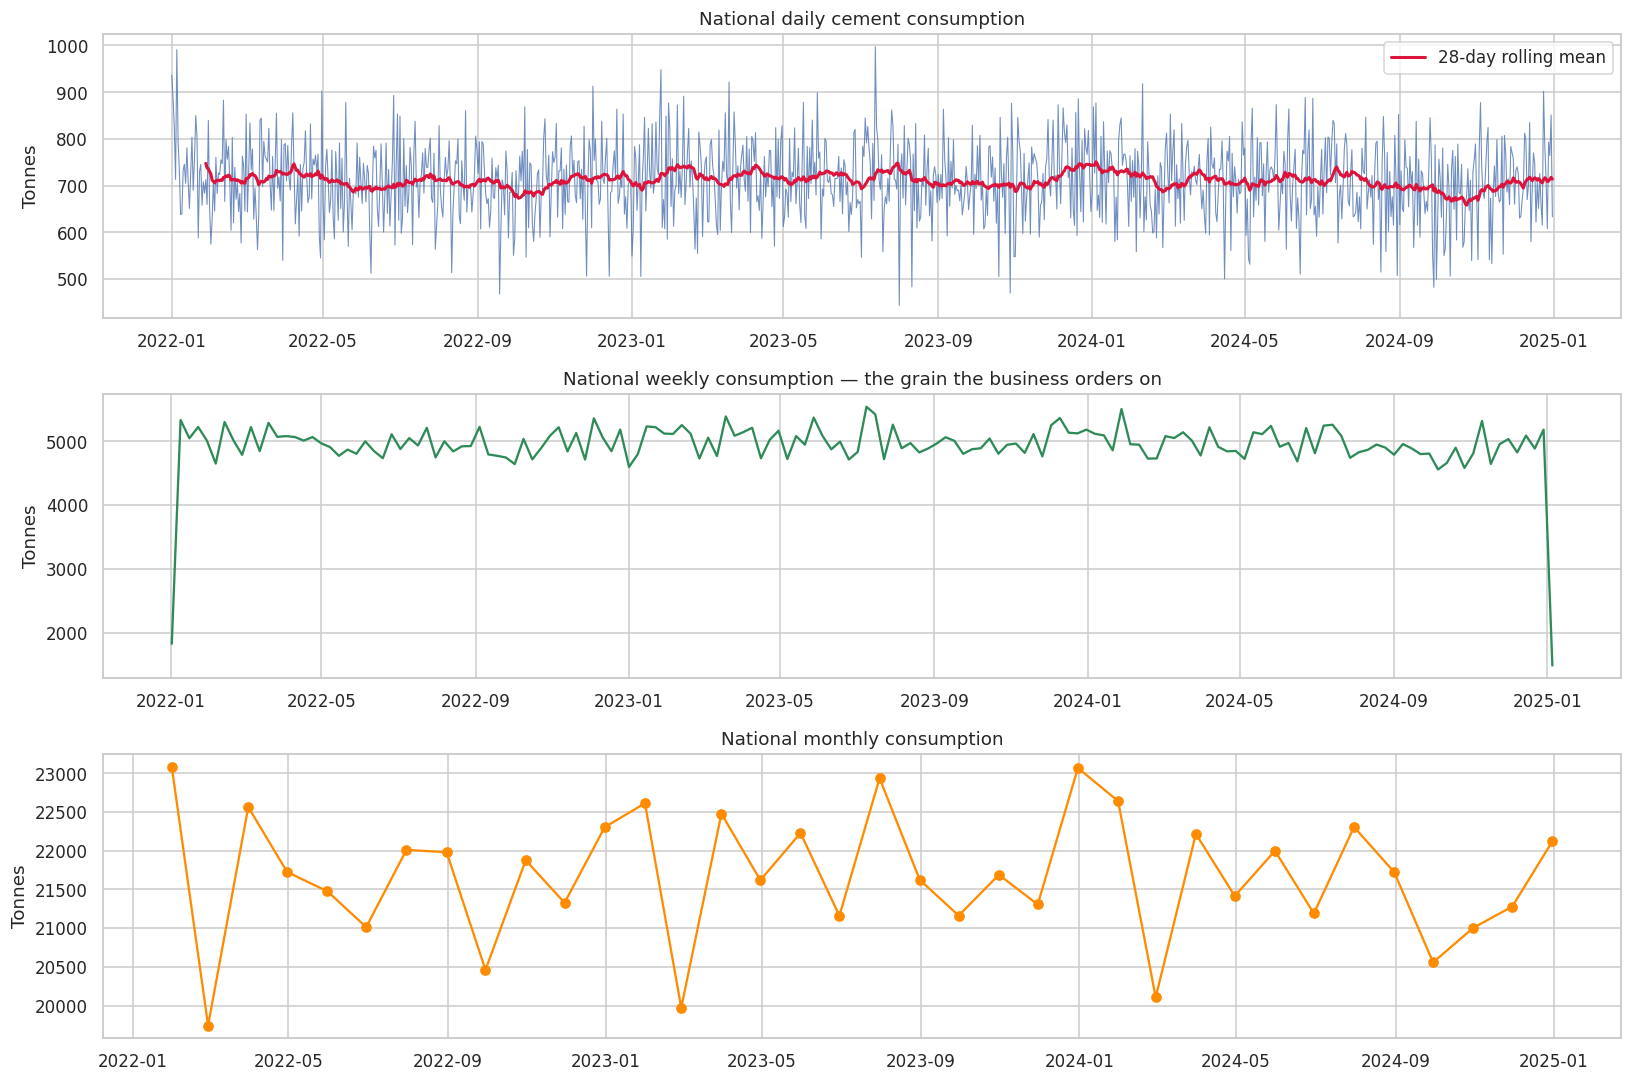

Daily national total   mean 712 t   sd 82 t
Weekly national total  mean 4,936 t   sd 424 t


In [19]:
national_daily = panel.groupby("date")["consumed_tonnes"].sum().asfreq("D")
national_weekly = national_daily.resample("W").sum()
national_monthly = national_daily.resample("ME").sum()

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

axes[0].plot(national_daily.index, national_daily.values, linewidth=0.7, alpha=0.8)
axes[0].plot(national_daily.index, national_daily.rolling(28).mean(),
             color="crimson", linewidth=2, label="28-day rolling mean")
axes[0].set_title("National daily cement consumption")
axes[0].set_ylabel("Tonnes")
axes[0].legend()

axes[1].plot(national_weekly.index, national_weekly.values, color="seagreen")
axes[1].set_title("National weekly consumption — the grain the business orders on")
axes[1].set_ylabel("Tonnes")

axes[2].plot(national_monthly.index, national_monthly.values, marker="o", color="darkorange")
axes[2].set_title("National monthly consumption")
axes[2].set_ylabel("Tonnes")

plt.tight_layout()
save_fig("temporal_trend")
plt.show()

print(f"Daily national total   mean {national_daily.mean():,.0f} t   sd {national_daily.std():,.0f} t")
print(f"Weekly national total  mean {national_weekly.mean():,.0f} t   sd {national_weekly.std():,.0f} t")

Grand mean: 23.72 t per site-day

Weekday peak-to-trough: 0.67 t (2.8% of the mean)
Monthly peak-to-trough: 1.46 t (6.2% of the mean)  (highest month 1, lowest 9)
Yearly  peak-to-trough: 0.37 t (1.5% of the mean)


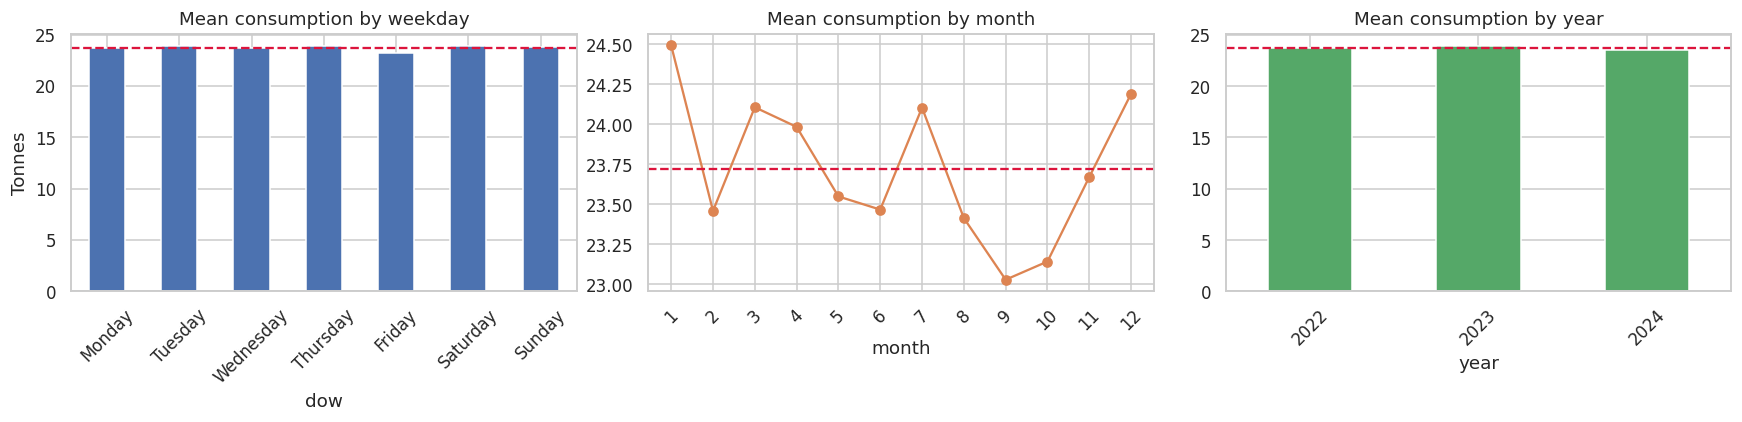

In [20]:
panel["dow"] = panel["date"].dt.day_name()
panel["month"] = panel["date"].dt.month
panel["year"] = panel["date"].dt.year

grand_mean = panel["consumed_tonnes"].mean()
dow_mean = panel.groupby("dow")["consumed_tonnes"].mean().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
month_mean = panel.groupby("month")["consumed_tonnes"].mean()
year_mean = panel.groupby("year")["consumed_tonnes"].mean()

def spread(s):
    return f"{s.max() - s.min():.2f} t ({100 * (s.max() - s.min()) / grand_mean:.1f}% of the mean)"

print(f"Grand mean: {grand_mean:.2f} t per site-day\n")
print(f"Weekday peak-to-trough: {spread(dow_mean)}")
print(f"Monthly peak-to-trough: {spread(month_mean)}  (highest month {month_mean.idxmax()}, lowest {month_mean.idxmin()})")
print(f"Yearly  peak-to-trough: {spread(year_mean)}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
dow_mean.plot(kind="bar", ax=axes[0], color="#4c72b0")
axes[0].set_title("Mean consumption by weekday")
axes[0].set_ylabel("Tonnes")
month_mean.plot(marker="o", ax=axes[1], color="#dd8452")
axes[1].set_title("Mean consumption by month")
axes[1].set_xticks(range(1, 13))
year_mean.plot(kind="bar", ax=axes[2], color="#55a868")
axes[2].set_title("Mean consumption by year")
for ax in axes:
    ax.axhline(grand_mean, color="crimson", linestyle="--")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
save_fig("seasonality_effect_sizes")
plt.show()

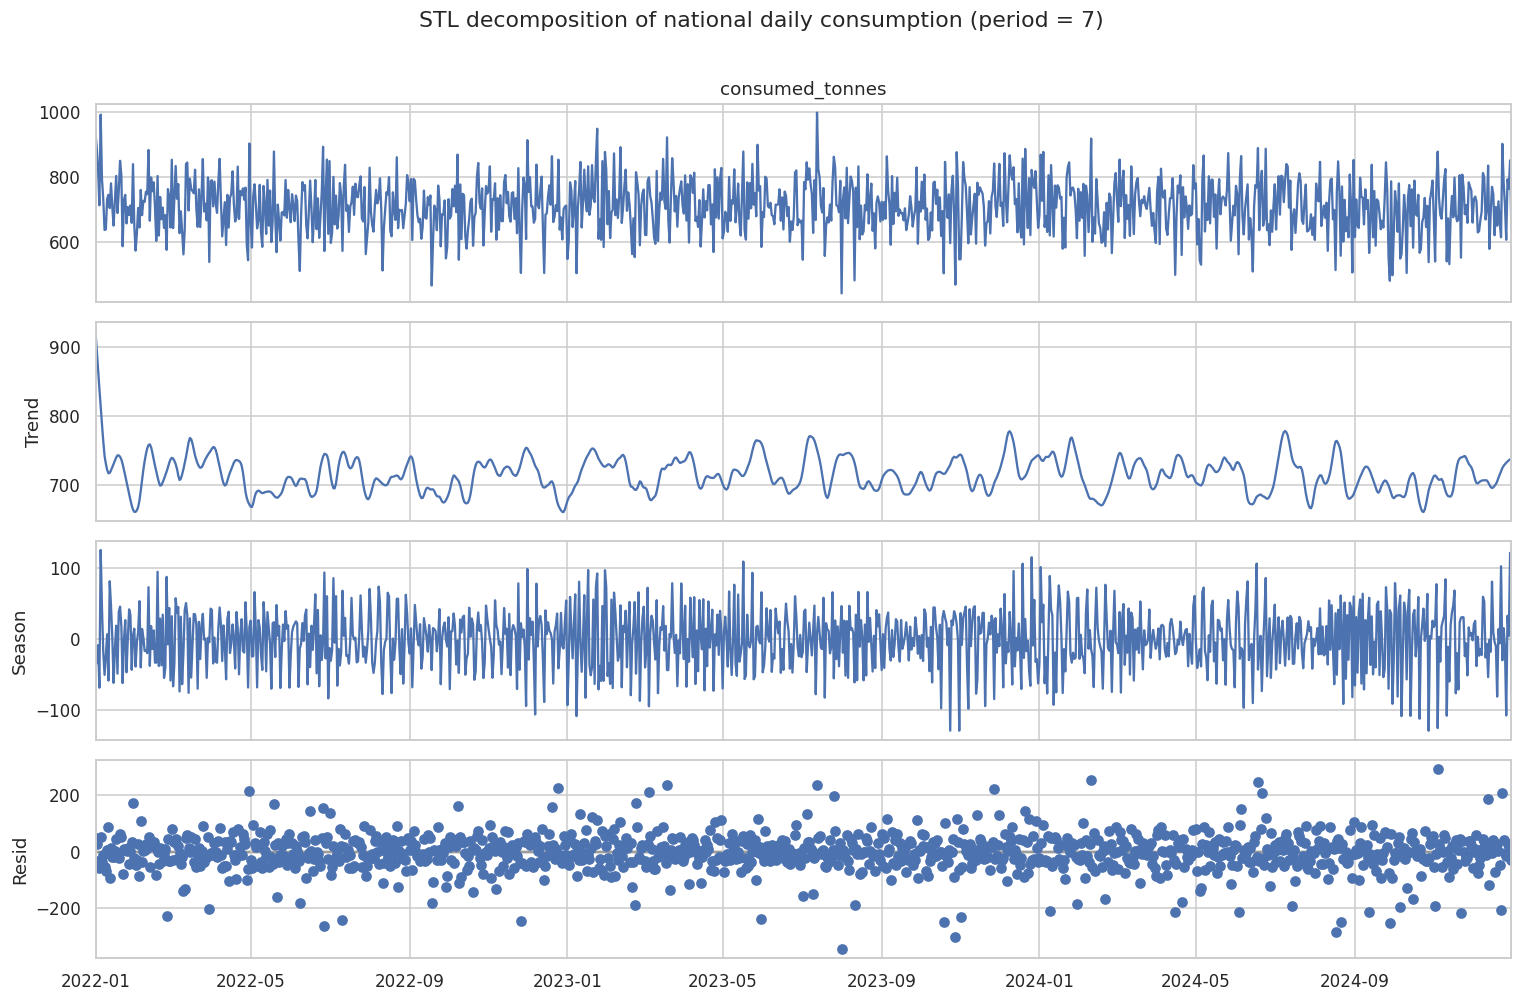

Variance share — trend    : 9.70%
Variance share — seasonal : 25.41%
Variance share — residual : 64.89%
Seasonal strength         : 0.281  (below ~0.6 is weak)


In [21]:
stl = STL(national_daily, period=7, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(14, 9)
plt.suptitle("STL decomposition of national daily consumption (period = 7)", y=1.01)
plt.tight_layout()
save_fig("stl_decomposition")
plt.show()

v_trend, v_seasonal, v_resid = np.var(stl.trend), np.var(stl.seasonal), np.var(stl.resid)
total = v_trend + v_seasonal + v_resid
print(f"Variance share — trend    : {v_trend / total:.2%}")
print(f"Variance share — seasonal : {v_seasonal / total:.2%}")
print(f"Variance share — residual : {v_resid / total:.2%}")
print(f"Seasonal strength         : {max(0, 1 - v_resid / (v_seasonal + v_resid)):.3f}  (below ~0.6 is weak)")

**Demand is flat.** There is no trend across the three years (yearly means 23.70,
23.91, 23.55 t) and no calendar cycle worth the name:

| cycle | peak-to-trough | as % of the mean |
|---|---|---|
| weekday | 0.67 t | 2.8% |
| month | 1.46 t | 6.2% |
| year | 0.37 t | 1.5% |

Construction here does not slow at weekends or in winter — Saturday and Sunday
are indistinguishable from Wednesday.

The STL output needs reading carefully, because taken at face value it disagrees.
It assigns 25.4% of variance to a "seasonal" component, but seasonal *strength*
is only 0.281, and STL permits that component to evolve over time, so on a
near-random series it absorbs short-run wiggle rather than a repeating cycle. The
decisive figure is in section 10: a **fixed** weekday effect explains 0.0% of
panel variance and a fixed month effect 0.1%. A component that cannot be pinned
to a repeating calendar position is not something a forecast can use.

Practically: seasonal ARIMA terms have nothing to work on, and calendar features
(weekday, month, week-of-year) should be dropped rather than carried through
modelling as noise.

## 9 — Autocorrelation

Whether today's consumption tells you anything about tomorrow's. This determines whether
lag and rolling-average features — the standard opening move on any time series —
are worth building here.

In [22]:
site_series = panel.sort_values(["site_id", "date"]).groupby("site_id")["consumed_tonnes"]
LAGS = [1, 2, 3, 7, 14, 21, 28]

acf_by_site = pd.DataFrame({lag: site_series.apply(lambda s, l=lag: s.autocorr(l)) for lag in LAGS})
acf_summary = pd.DataFrame({
    "mean across sites": acf_by_site.mean(),
    "min": acf_by_site.min(),
    "max": acf_by_site.max(),
    "sites with |r| > 0.10": (acf_by_site.abs() > 0.10).sum(),
}).round(4)
acf_summary.index.name = "lag (days)"
display(acf_summary)

print(f"95% white-noise band for a single 1,096-day series: +/- {1.96 / np.sqrt(1096):.3f}")

,mean across sites,min,max,sites with |r| > 0.10
lag (days),,,,
1,-0.015,-0.066,0.055,0
2,-0.013,-0.080,0.058,0
3,-0.014,-0.072,0.059,0
7,-0.001,-0.078,0.088,0
14,0.004,-0.045,0.065,0
21,0.005,-0.080,0.058,0
28,0.008,-0.054,0.061,0


95% white-noise band for a single 1,096-day series: +/- 0.059


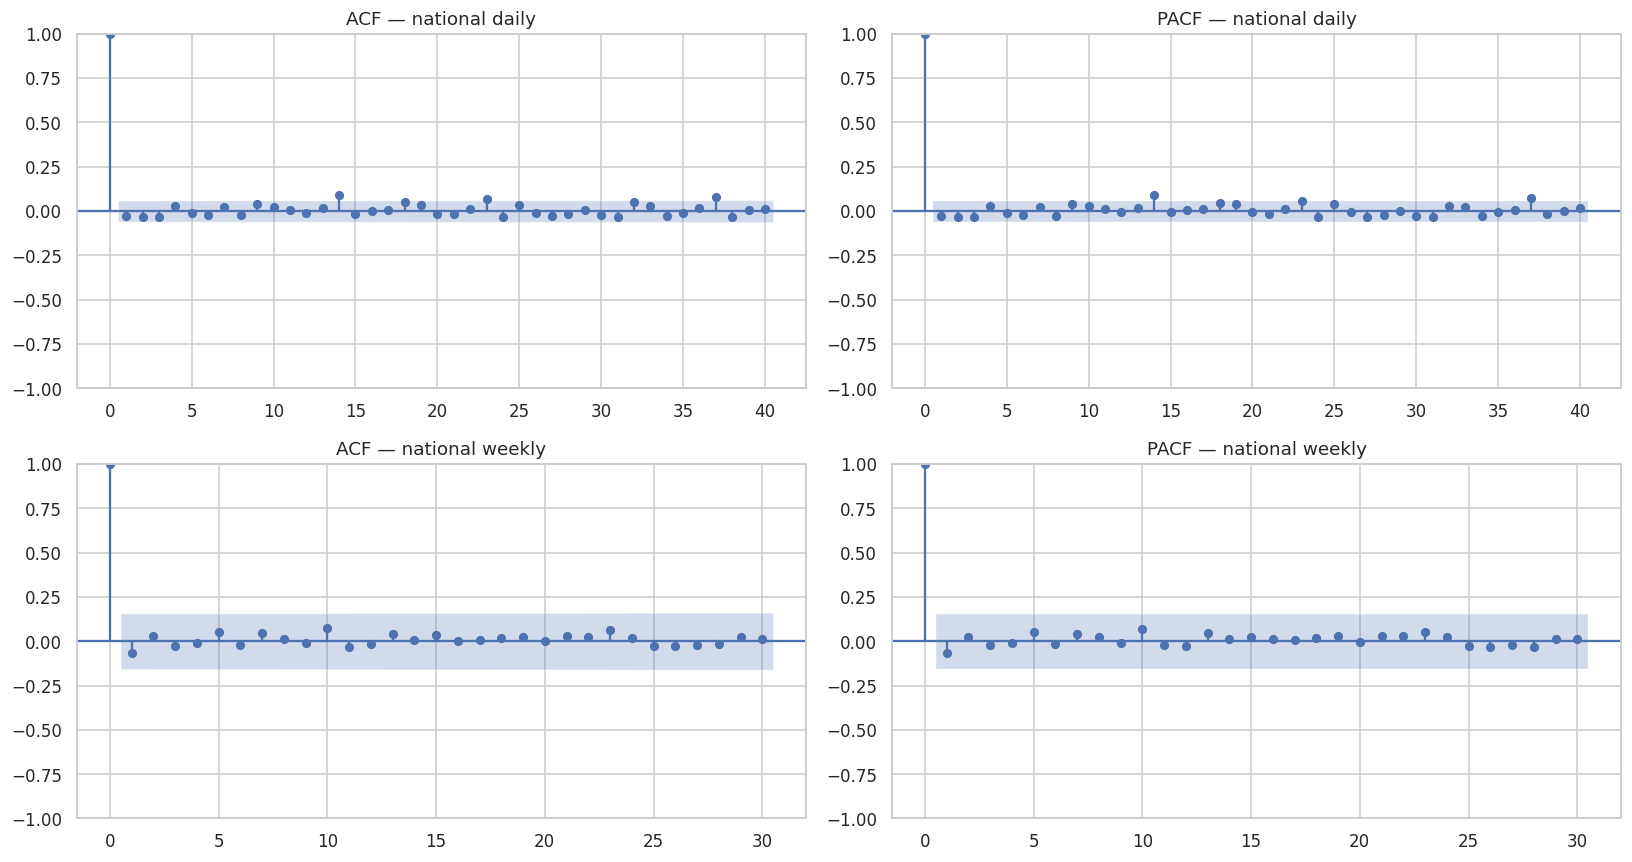

National daily  lag 1 : -0.030
National daily  lag 7 : +0.024
National weekly lag 1 : -0.109


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
plot_acf(national_daily, lags=40, ax=axes[0, 0]); axes[0, 0].set_title("ACF — national daily")
plot_pacf(national_daily, lags=40, ax=axes[0, 1], method="ywm"); axes[0, 1].set_title("PACF — national daily")
plot_acf(national_weekly, lags=30, ax=axes[1, 0]); axes[1, 0].set_title("ACF — national weekly")
plot_pacf(national_weekly, lags=30, ax=axes[1, 1], method="ywm"); axes[1, 1].set_title("PACF — national weekly")
plt.tight_layout()
save_fig("acf_pacf")
plt.show()

print(f"National daily  lag 1 : {national_daily.autocorr(1):+.3f}")
print(f"National daily  lag 7 : {national_daily.autocorr(7):+.3f}")
print(f"National weekly lag 1 : {national_weekly.autocorr(1):+.3f}")

In [24]:
# Does the scheduled driver carry the memory instead?
planned_series = panel.sort_values(["site_id", "date"]).groupby("site_id")["planned_pour_tonnes"]
planned_acf = pd.Series(
    {lag: planned_series.apply(lambda s, l=lag: s.autocorr(l)).mean() for lag in LAGS})

comparison = pd.concat([
    acf_by_site.mean().rename("consumed_tonnes"),
    planned_acf.rename("planned_pour_tonnes"),
], axis=1).round(4)
comparison.index.name = "lag (days)"
display(comparison)

,consumed_tonnes,planned_pour_tonnes
lag (days),,
1,-0.015,0.001
2,-0.013,0.001
3,-0.014,0.003
7,-0.001,-0.005
14,0.004,0.005
21,0.005,0.003
28,0.008,0.002


**The series has no memory at any lag or any grain.** Mean site-level
autocorrelation is −0.015 at lag 1, −0.001 at lag 7, +0.004 at lag 14 and +0.008
at lag 28. More convincingly, **no individual site exceeds |r| = 0.10 at any
lag** — so this is not opposite-signed site effects cancelling in the average.
The national daily and weekly ACF and PACF sit inside the white-noise band
throughout, and `planned_pour_tonnes` is equally memoryless.

Each site-day is drawn essentially independently of the one before it. That is
unusual for demand data and it is the single most consequential structural fact
in the panel:

- Lag and rolling-statistic features carry no information here. Building them
  costs warm-up rows, adds leakage surface and dilutes tree splits for nothing.
- ARIMA-family models have nothing to fit. With no AR or MA structure and no
  seasonality, SARIMAX reduces to an ordinary regression on its exogenous
  regressors — worth fitting once as a documented baseline, not worth scripting
  30 per-site fits for.
- All the predictive signal must be contemporaneous and exogenous, which is what
  sections 12 and 16 confirm.

## 10 — Where demand variation comes from

Consumption varies from 0 to 87 t across the panel. This section attributes that
variation to the structural dimensions available: which site, which operating
behaviour, which region, which cement grade, which day.

,groups,variance share
grouping,,
site_id,30,0.231
behavior,3,0.230
region,4,0.015
cement_type,3,0.000
dow,7,0.000
month,12,0.001


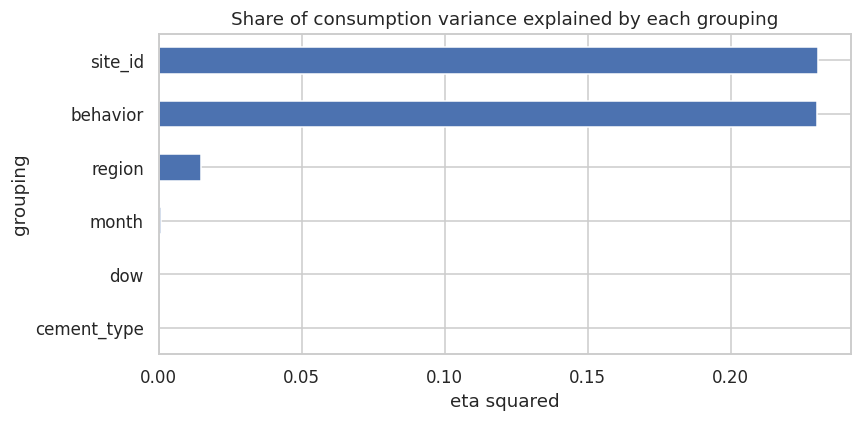

In [25]:
grand = panel["consumed_tonnes"].mean()
ss_total = ((panel["consumed_tonnes"] - grand) ** 2).sum()

rows = []
for key in ["site_id", "behavior", "region", "cement_type", "dow", "month"]:
    group_mean = panel.groupby(key)["consumed_tonnes"].transform("mean")
    rows.append({
        "grouping": key,
        "groups": panel[key].nunique(),
        "variance share": ((group_mean - grand) ** 2).sum() / ss_total,
    })
decomp = pd.DataFrame(rows).set_index("grouping")
decomp["variance share"] = decomp["variance share"].round(4)
display(decomp)

plt.figure(figsize=(8, 4))
decomp["variance share"].sort_values().plot(kind="barh", color="#4c72b0")
plt.title("Share of consumption variance explained by each grouping")
plt.xlabel("eta squared")
plt.tight_layout()
save_fig("variance_decomposition")
plt.show()

In [26]:
# Once behaviour is accounted for, is there any site effect left?
resid = panel["consumed_tonnes"] - panel.groupby("behavior")["consumed_tonnes"].transform("mean")
ss_total_r = ((resid - resid.mean()) ** 2).sum()
ss_between_r = ((resid.groupby(panel["site_id"]).transform("mean") - resid.mean()) ** 2).sum()

print(f"Site variance share, unconditional             : {decomp.loc['site_id', 'variance share']:.2%}")
print(f"Behaviour variance share, unconditional        : {decomp.loc['behavior', 'variance share']:.2%}")
print(f"Site variance share, after removing behaviour  : {ss_between_r / ss_total_r:.2%}")

Site variance share, unconditional             : 23.06%
Behaviour variance share, unconditional        : 23.02%
Site variance share, after removing behaviour  : 0.05%


,actual regional mean,predicted from behaviour mix alone,difference
region,,,
East,24.250,24.330,-0.070
North,17.590,17.690,-0.090
South,24.460,24.390,0.070
West,24.690,24.590,0.090


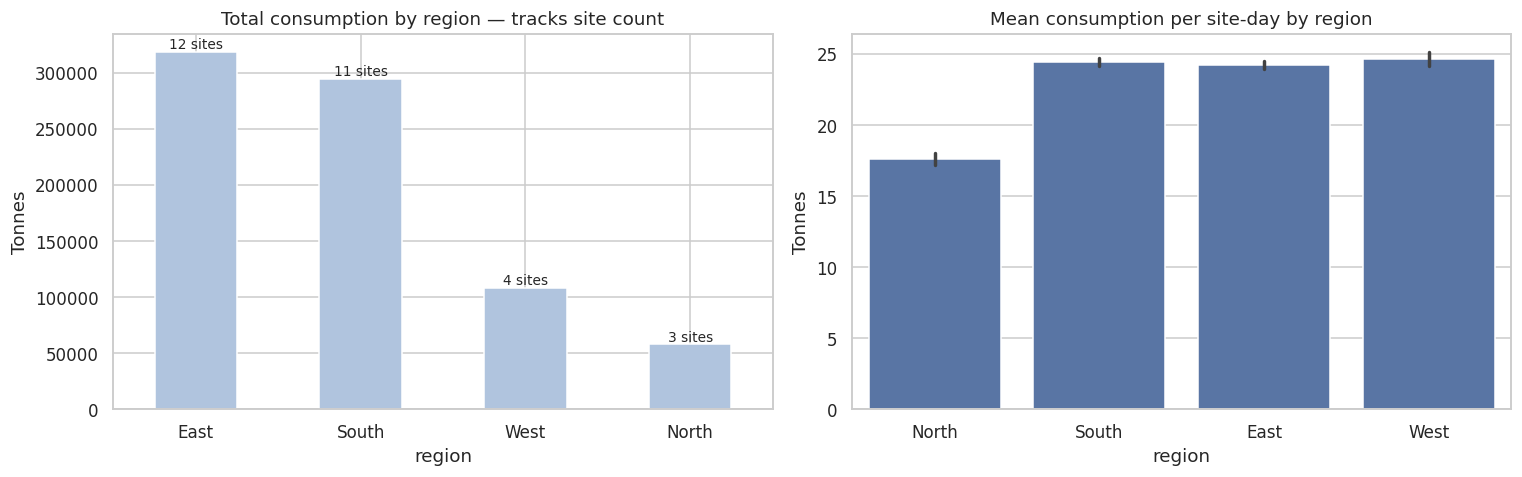

In [27]:
# Is the regional difference anything more than a different mix of behaviours?
behaviour_means = sites.groupby("behavior")["mean_consumed"].mean()
region_actual = sites.groupby("region")["mean_consumed"].mean()
region_predicted = sites.groupby("region")["behavior"].apply(lambda s: s.map(behaviour_means).mean())

display(pd.DataFrame({
    "actual regional mean": region_actual,
    "predicted from behaviour mix alone": region_predicted,
    "difference": region_actual - region_predicted,
}).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
region_summary = panel.groupby("region").agg(
    sites=("site_id", "nunique"), total=("consumed_tonnes", "sum"),
).sort_values("total", ascending=False)
region_summary["total"].plot(kind="bar", ax=axes[0], color="lightsteelblue")
for i, (tot, n) in enumerate(zip(region_summary["total"], region_summary["sites"])):
    axes[0].text(i, tot, f"{n} sites", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Total consumption by region — tracks site count")
axes[0].set_ylabel("Tonnes")
sns.barplot(data=panel, x="region", y="consumed_tonnes", estimator="mean",
            errorbar=("ci", 95), ax=axes[1])
axes[1].set_title("Mean consumption per site-day by region")
axes[1].set_ylabel("Tonnes")
for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
save_fig("region_effect")
plt.show()

**Variation is behavioural, and nothing else.**

| grouping | groups | variance share |
|---|---|---|
| `site_id` | 30 | **23.1%** |
| `behavior` | 3 | **23.0%** |
| `region` | 4 | 1.5% |
| `cement_type` | 3 | 0.0% |
| weekday | 7 | 0.0% |
| month | 12 | 0.1% |

Thirty site dummies and three behaviour levels explain the same variance. After
removing the behaviour means, the residual between-site share is **0.05%** — the
30-site bar chart in section 5 is really a three-group chart.

**Region has no independent effect whatsoever.** Predicting each region's mean
from nothing but its mix of behaviours reproduces the actual figure to within
0.1 t for all four regions. North looks different (17.6 t against ~24.4 t
elsewhere) purely because its three sites happen to be two conservative and one
aggressive. Ranking regions by *total* consumption is worse still — it ranks them
by how many sites they contain (East 12, North 3).

Together with section 6, this says the structure of the panel is: **one global
model, with `behavior` carrying the site heterogeneity.** Thirty per-site models
would fit the same three-way structure on a thirtieth of the data each, and
`region` can be dropped.

## 11 — Cement types

Three grades appear in the panel: CEM_I, CEM_II and CEM_III, one per site-day.

In [28]:
type_profile = panel.groupby("cement_type").agg(
    rows=("consumed_tonnes", "size"),
    share=("consumed_tonnes", lambda s: len(s) / len(panel)),
    mean_planned=("planned_pour_tonnes", "mean"),
    mean_consumed=("consumed_tonnes", "mean"),
    sd_consumed=("consumed_tonnes", "std"),
    pct_constrained=("was_constrained", lambda s: 100 * s.mean()),
).round(3)
display(type_profile)

# How does the grade change from one day to the next within a site?
panel["next_type"] = panel.groupby("site_id")["cement_type"].shift(-1)
transitions = pd.crosstab(panel["cement_type"], panel["next_type"], normalize="index").round(3)
print("Probability of tomorrow's grade given today's (rows sum to 1):")
display(transitions)

,rows,share,mean_planned,mean_consumed,sd_consumed,pct_constrained
cement_type,,,,,,
CEM_I,10913,0.332,30.963,23.821,16.848,40.273
CEM_II,11097,0.338,30.596,23.738,16.773,39.335
CEM_III,10870,0.331,30.534,23.602,16.920,39.476


Probability of tomorrow's grade given today's (rows sum to 1):


next_type,CEM_I,CEM_II,CEM_III
cement_type,,,
CEM_I,0.330,0.340,0.330
CEM_II,0.334,0.334,0.332
CEM_III,0.332,0.338,0.330


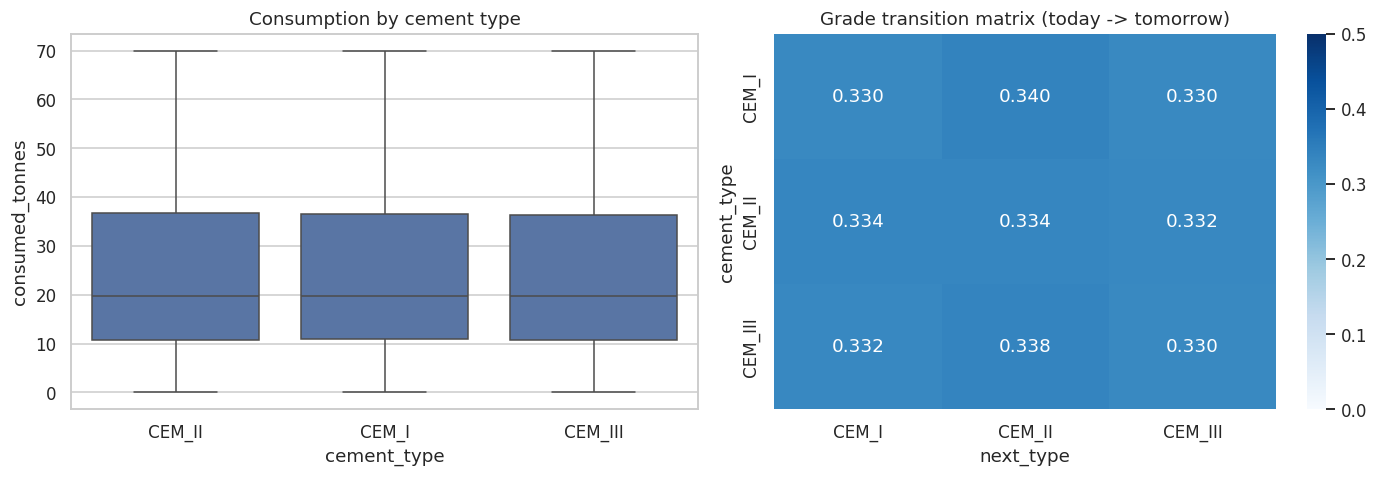

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=panel, x="cement_type", y="consumed_tonnes", ax=axes[0])
axes[0].set_title("Consumption by cement type")
sns.heatmap(transitions, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=0.5, ax=axes[1])
axes[1].set_title("Grade transition matrix (today -> tomorrow)")
plt.tight_layout()
save_fig("cement_type")
plt.show()

The three grades are used in equal proportion (33.2% / 33.8% / 33.1%), have
statistically identical demand distributions (means 23.82, 23.74, 23.60 t), and
explain 0.0% of consumption variance.

The transition matrix settles what they are: every cell is close to 0.333, so
tomorrow's grade is independent of today's. Cement type is drawn at random each
day rather than following any production schedule — which means it is not merely
uninformative as a predictor, it is **unforecastable in principle**.

It should still be carried through the pipeline for inventory reporting and silo
allocation, since the business orders in grades. It should not be expected to
contribute to a demand model.

## 12 — Weather

The panel carries daily rainfall and mean temperature per site. Rain correlates
with consumption at r = −0.18 and temperature at r = +0.04, which suggests a mild
linear drag from rain and nothing from temperature. Neither reading survives a
closer look.

,mean_rain_mm,pct_days_above_threshold,mean_temp_c
month,,,
1,4.960,4.870,12.490
2,5.100,5.330,16.970
3,5.120,5.050,19.590
4,5.100,4.780,19.760
5,4.970,4.730,17.090
6,5.040,5.370,12.800
7,5.020,4.730,7.840
8,5.060,4.980,3.140
9,4.980,5.520,0.910


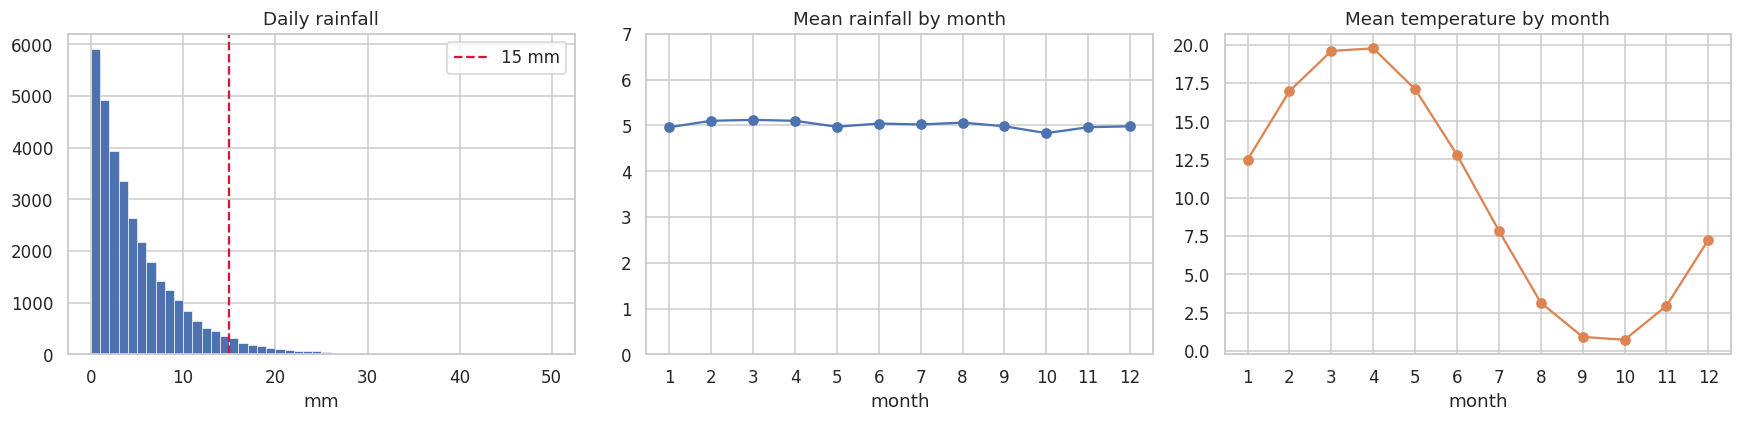

Rainfall: median 3.47 mm, 95th pct 14.97 mm, max 50.0 mm
Temperature range: -5.0 to 35.0 C


In [30]:
weather_by_month = panel.groupby("month").agg(
    mean_rain_mm=("rain_mm", "mean"),
    pct_days_above_threshold=("rain_mm", lambda s: 100 * (s > RAIN_STOPPAGE_MM).mean()),
    mean_temp_c=("avg_temp_c", "mean"),
).round(2)
display(weather_by_month)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(panel["rain_mm"], bins=50, color="#4c72b0", edgecolor="white", linewidth=0.4)
axes[0].axvline(RAIN_STOPPAGE_MM, color="crimson", linestyle="--", label=f"{RAIN_STOPPAGE_MM:g} mm")
axes[0].set_title("Daily rainfall"); axes[0].set_xlabel("mm"); axes[0].legend()
weather_by_month["mean_rain_mm"].plot(marker="o", ax=axes[1], color="#4c72b0")
axes[1].set_title("Mean rainfall by month"); axes[1].set_ylim(0, 7); axes[1].set_xticks(range(1, 13))
weather_by_month["mean_temp_c"].plot(marker="o", ax=axes[2], color="#dd8452")
axes[2].set_title("Mean temperature by month"); axes[2].set_xticks(range(1, 13))
plt.tight_layout()
save_fig("weather_profile")
plt.show()

print(f"Rainfall: median {panel['rain_mm'].median():.2f} mm, 95th pct {panel['rain_mm'].quantile(0.95):.2f} mm, max {panel['rain_mm'].max():.1f} mm")
print(f"Temperature range: {panel['avg_temp_c'].min():.1f} to {panel['avg_temp_c'].max():.1f} C")

Before looking at the effect on demand, note the two exogenous series have
opposite structures.

**Rainfall has no seasonality at all.** Monthly means sit between 4.83 and
5.12 mm, and the share of days above 15 mm is between 4.1% and 5.5% in every
month of the year. Heavy rain arrives as a flat ~4.9% daily hazard.

**Temperature is strongly seasonal**, running from 0.7 °C in October to 19.8 °C
in April. It is the one variable in the panel with a clean annual cycle — and,
as the correlation shows, the one that has no bearing on how much cement gets
poured.

In [31]:
rain_bins = [0, 2, 5, 8, 10, 12, 14, 15, 16, 20, 50]
panel["rain_band"] = pd.cut(panel["rain_mm"], bins=rain_bins, include_lowest=True)

rain_profile = panel.groupby("rain_band", observed=False).apply(
    lambda g: pd.Series({
        "rows": len(g),
        "mean planned (t)": g["planned_pour_tonnes"].mean(),
        "mean consumed (t)": g["consumed_tonnes"].mean(),
        "zero-consumption days %": 100 * (g["consumed_tonnes"] == 0).mean(),
        "demand fill rate %": 100 * g["consumed_tonnes"].sum() / g["planned_pour_tonnes"].sum(),
    }), include_groups=False,
).round(2)
display(rain_profile)

,rows,mean planned (t),mean consumed (t),zero-consumption days %,demand fill rate %
rain_band,,,,,
"(-0.001, 2.0]","10,877.000",30.670,24.680,9.260,80.480
"(2.0, 5.0]","9,909.000",30.570,24.710,9.460,80.830
"(5.0, 8.0]","5,362.000",30.980,24.930,8.910,80.460
"(8.0, 10.0]","2,303.000",30.470,24.500,9.510,80.410
"(10.0, 12.0]","1,480.000",31.110,25.250,9.120,81.170
"(12.0, 14.0]",963.000,30.610,24.800,9.550,81.010
"(14.0, 15.0]",359.000,30.900,24.560,8.640,79.480
"(15.0, 16.0]",314.000,31.490,3.950,68.150,12.540
"(16.0, 20.0]",694.000,30.140,3.890,68.010,12.920


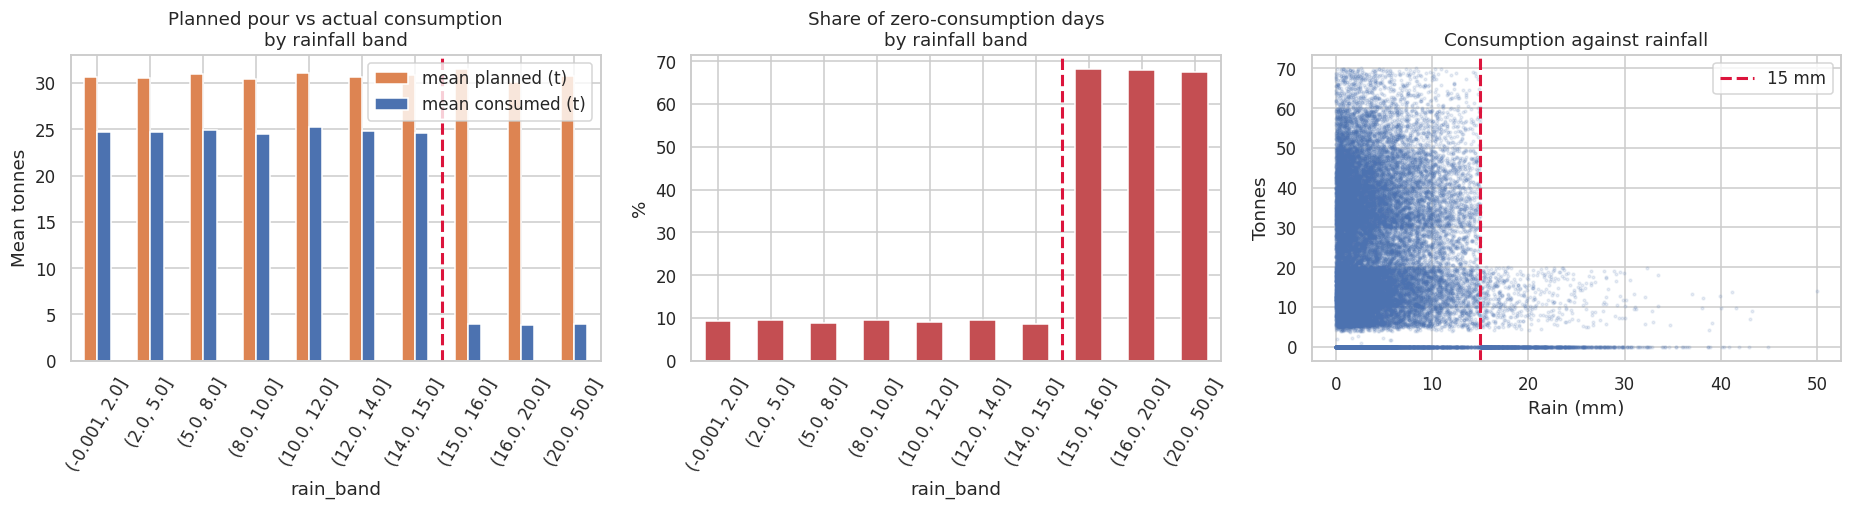

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

rain_profile[["mean planned (t)", "mean consumed (t)"]].plot(
    kind="bar", ax=axes[0], color=["#dd8452", "#4c72b0"])
axes[0].set_title("Planned pour vs actual consumption\nby rainfall band")
axes[0].set_ylabel("Mean tonnes")

rain_profile["zero-consumption days %"].plot(kind="bar", ax=axes[1], color="#c44e52")
axes[1].set_title("Share of zero-consumption days\nby rainfall band")
axes[1].set_ylabel("%")

axes[2].scatter(panel["rain_mm"], panel["consumed_tonnes"], s=3, alpha=0.12)
axes[2].axvline(RAIN_STOPPAGE_MM, color="crimson", linestyle="--", linewidth=2,
                label=f"{RAIN_STOPPAGE_MM:g} mm")
axes[2].set_title("Consumption against rainfall")
axes[2].set_xlabel("Rain (mm)"); axes[2].set_ylabel("Tonnes"); axes[2].legend()

for ax in axes[:2]:
    ax.tick_params(axis="x", rotation=60)
    ax.axvline(6.5, color="crimson", linestyle="--", linewidth=2)
plt.tight_layout()
save_fig("rain_threshold")
plt.show()

In [33]:
above = panel[panel["rain_mm"] > RAIN_STOPPAGE_MM]
below = panel[panel["rain_mm"] <= RAIN_STOPPAGE_MM]

display(pd.DataFrame({
    f"rain <= {RAIN_STOPPAGE_MM:g} mm": [
        len(below), below["planned_pour_tonnes"].mean(), below["consumed_tonnes"].mean(),
        100 * (below["consumed_tonnes"] == 0).mean(),
        below["rain_mm"].corr(below["consumed_tonnes"]),
    ],
    f"rain > {RAIN_STOPPAGE_MM:g} mm": [
        len(above), above["planned_pour_tonnes"].mean(), above["consumed_tonnes"].mean(),
        100 * (above["consumed_tonnes"] == 0).mean(),
        above["rain_mm"].corr(above["consumed_tonnes"]),
    ],
}, index=["rows", "mean planned (t)", "mean consumed (t)",
          "zero-consumption days %", "corr(rain, consumed) within band"]).round(3))

print(f"Pooled corr(rain, consumed)              : {panel['rain_mm'].corr(panel['consumed_tonnes']):+.3f}")
print(f"Corr restricted to rain <= {RAIN_STOPPAGE_MM:g} mm        : {below['rain_mm'].corr(below['consumed_tonnes']):+.3f}")
print(f"Share of all zero-consumption rows above {RAIN_STOPPAGE_MM:g} mm: "
      f"{(panel.loc[panel['consumed_tonnes'] == 0, 'rain_mm'] > RAIN_STOPPAGE_MM).mean():.1%}")
print(f"\nMean planned pour either side of the break: "
      f"{below['planned_pour_tonnes'].mean():.2f} t vs {above['planned_pour_tonnes'].mean():.2f} t")

,rain <= 15 mm,rain > 15 mm
rows,"31,253.000","1,627.000"
mean planned (t),30.700,30.645
mean consumed (t),24.750,3.945
zero-consumption days %,9.276,67.855
"corr(rain, consumed) within band",0.005,0.012


Pooled corr(rain, consumed)              : -0.180
Corr restricted to rain <= 15 mm        : +0.005
Share of all zero-consumption rows above 15 mm: 27.6%

Mean planned pour either side of the break: 30.70 t vs 30.65 t


**Rain acts as a switch at 15.0 mm, not a gradient.**

| | rain ≤ 15 mm | rain > 15 mm |
|---|---|---|
| rows | 31,253 (95.1%) | 1,627 (4.9%) |
| mean **planned** pour | 30.70 t | 30.65 t |
| mean **consumed** | 24.75 t | **3.95 t** |
| zero-consumption days | 9.3% | **67.9%** |
| corr(rain, consumed) *within* the band | **+0.005** | +0.012 |

Below the threshold, rainfall has no relationship with consumption at all
(r = +0.005). The entire pooled r = −0.18 is the threshold leaking into a linear
statistic — a textbook case of a step function read as a slope.

Planned pour is unchanged either side of the break (30.70 t against 30.65 t), so
this is scheduled work being **cancelled**, not less work being wanted. Heavy
rain accounts for 27.6% of every zero-consumption row in the panel.

For modelling this means a binary `rain_stoppage = rain_mm > 15` feature, and
dropping raw `rain_mm` — once the flag is present the underlying millimetres are
close to pure noise, and a linear coefficient on them misrepresents the physics.
`avg_temp_c` can be dropped outright.

One practical caveat, which the flat monthly profile above makes concrete: at
inference the flag needs a rainfall *forecast*, and since heavy rain has no
seasonal structure, an 8-week-ahead forecast can do no better than the
climatological base rate of ~4.9%. The honest production form is therefore
expected demand = planned pour × P(rain ≤ 15 mm), and that irreducible
uncertainty caps long-horizon accuracy regardless of which model is chosen.

## 13 — Planned versus actual

39.7% of site-days consumed less cement than was scheduled. `consumed_tonnes` is
therefore *observed* demand rather than *true* demand — it records what the silo
allowed, not what the site wanted. This section describes the size and the cause
of that gap.

In [34]:
totals = pd.Series({
    "Planned pour (t)": panel["planned_pour_tonnes"].sum(),
    "Consumed, as recorded (t)": panel["consumed_tonnes"].sum(),
    "Served, post ledger repair (t)": panel["served_tonnes"].sum(),
    "Unmet against plan (t)": panel["unmet_tonnes"].sum(),
    "Deliveries offered (t)": panel["deliveries_tonnes"].sum(),
    "Deliveries accepted (t)": panel["received_tonnes"].sum(),
    "Deliveries turned away (t)": panel["rejected_delivery_tonnes"].sum(),
})
recon = totals.round(0).to_frame("tonnes")
recon["% of planned"] = (100 * totals / totals["Planned pour (t)"]).round(1)
display(recon)

print(f"Overall demand fill rate: {100 * panel['consumed_tonnes'].sum() / panel['planned_pour_tonnes'].sum():.1f}%")
print(f"Rows where consumption fell short of plan: {panel['was_constrained'].mean():.1%}")

,tonnes,% of planned
Planned pour (t),"1,009,323.000",100.000
"Consumed, as recorded (t)","779,929.000",77.300
"Served, post ledger repair (t)","776,090.000",76.900
Unmet against plan (t),"229,393.000",22.700
Deliveries offered (t),"963,154.000",95.400
Deliveries accepted (t),"778,269.000",77.100
Deliveries turned away (t),"184,885.000",18.300


Overall demand fill rate: 77.3%
Rows where consumption fell short of plan: 39.7%


In [35]:
censoring = panel.groupby("behavior").apply(
    lambda g: pd.Series({
        "sites": g["site_id"].nunique(),
        "rows cut short %": 100 * g["was_constrained"].mean(),
        "planned (t)": g["planned_pour_tonnes"].sum(),
        "consumed (t)": g["consumed_tonnes"].sum(),
        "unmet (t)": g["unmet_tonnes"].sum(),
        "share of all unmet %": 100 * g["unmet_tonnes"].sum() / panel["unmet_tonnes"].sum(),
        "fill rate %": 100 * g["consumed_tonnes"].sum() / g["planned_pour_tonnes"].sum(),
    }), include_groups=False,
).reindex(BEHAVIOUR_ORDER).round(2)
display(censoring)

,sites,rows cut short %,planned (t),consumed (t),unmet (t),share of all unmet %,fill rate %
behavior,,,,,,,
aggressive,14.000,65.010,"655,736.130","460,446.940","195,289.190",85.130,70.220
chaotic,7.000,21.770,"236,428.500","205,800.440","30,628.060",13.350,87.050
conservative,9.000,14.250,"117,157.940","113,681.830","3,476.110",1.520,97.030


,rows,rows cut short %,fill rate %,mean unmet (t)
cover_band,,,,
"(-0.001, 0.25]","10,675.000",82.820,61.880,17.230
"(0.25, 0.5]","1,851.000",56.620,81.580,8.370
"(0.5, 0.75]","1,312.000",33.160,90.090,4.560
"(0.75, 1.0]","1,072.000",21.270,92.260,3.490
"(1.0, 2.0]","2,213.000",19.700,92.200,3.410
"(2.0, 5.0]","2,017.000",19.390,92.240,3.190
"(5.0, inf]","10,747.000",15.560,95.920,0.590


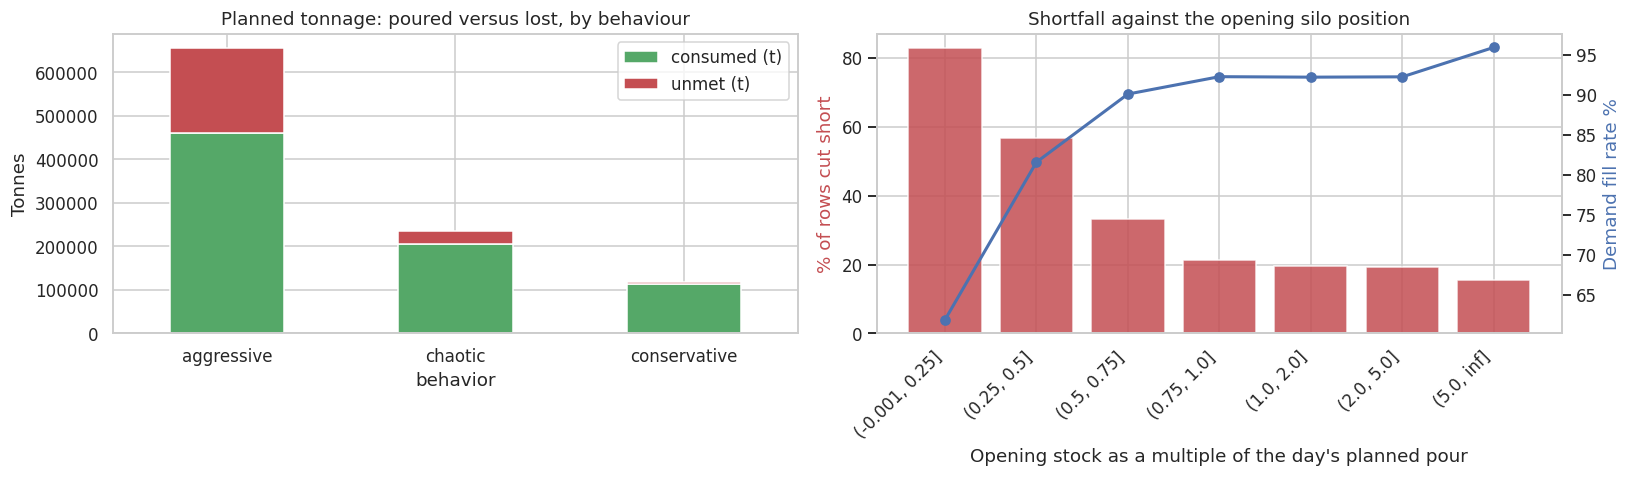

In [36]:
# The gap against the silo position the site started the day with.
panel["opening_cover"] = np.where(
    panel["planned_pour_tonnes"] > 0,
    panel["opening_inventory_tonnes"] / panel["planned_pour_tonnes"], np.nan)
panel["cover_band"] = pd.cut(panel["opening_cover"],
                             bins=[0, 0.25, 0.5, 0.75, 1.0, 2.0, 5.0, np.inf],
                             include_lowest=True)

cover_profile = panel.groupby("cover_band", observed=False).apply(
    lambda g: pd.Series({
        "rows": len(g),
        "rows cut short %": 100 * g["was_constrained"].mean(),
        "fill rate %": 100 * g["consumed_tonnes"].sum() / g["planned_pour_tonnes"].sum(),
        "mean unmet (t)": g["unmet_tonnes"].mean(),
    }), include_groups=False,
).round(2)
display(cover_profile)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

censoring[["consumed (t)", "unmet (t)"]].plot(kind="bar", stacked=True, ax=axes[0],
                                              color=["#55a868", "#c44e52"])
axes[0].set_title("Planned tonnage: poured versus lost, by behaviour")
axes[0].set_ylabel("Tonnes"); axes[0].tick_params(axis="x", rotation=0)

x = range(len(cover_profile))
axes[1].bar(x, cover_profile["rows cut short %"], color="#c44e52", alpha=0.85)
axes[1].set_ylabel("% of rows cut short", color="#c44e52")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels([str(i) for i in cover_profile.index], rotation=45, ha="right")
axes[1].set_xlabel("Opening stock as a multiple of the day's planned pour")
twin = axes[1].twinx()
twin.plot(x, cover_profile["fill rate %"], color="#4c72b0", marker="o", linewidth=2)
twin.set_ylabel("Demand fill rate %", color="#4c72b0"); twin.grid(False)
axes[1].set_title("Shortfall against the opening silo position")

plt.tight_layout()
save_fig("censoring")
plt.show()

**77.3% of planned cement was actually poured.** The missing 229,393 tonnes are
not spread evenly:

| behaviour | rows cut short | unmet (t) | share of all unmet | fill rate |
|---|---|---|---|---|
| aggressive | **65.0%** | 195,289 | **85.1%** | 70.2% |
| chaotic | 21.8% | 30,628 | 13.4% | 87.0% |
| conservative | 14.3% | 3,476 | 1.5% | 97.0% |

and the gap tracks the silo position at the start of the day almost perfectly:

| opening stock ÷ planned pour | rows | cut short | fill rate |
|---|---|---|---|
| under 0.25× | 10,675 | 82.8% | 61.9% |
| 0.25–0.5× | 1,851 | 56.6% | 81.6% |
| 0.5–0.75× | 1,312 | 33.2% | 90.1% |
| 0.75–1× | 1,072 | 21.3% | 92.3% |
| 1–2× | 2,213 | 19.7% | 92.2% |
| over 5× | 10,747 | 15.6% | 95.9% |

Combined with section 6, the mechanism is complete: silos were sized without
reference to throughput, cement arrives at a flat rate regardless of need, and
the sites that schedule the most work therefore run empty and lose a third of it.
Nothing here is a forecasting failure — the demand signal was known in advance in
every case. It is an ordering failure.

This has a direct consequence for the modelling target. **`consumed_tonnes` is
the output of the ordering policy the project exists to replace.** A model
trained on it learns to predict low demand exactly where stock has historically
been short, and will then recommend ordering less for precisely the sites that
most need more. The unconstrained demand signal is `planned_pour_tonnes`, and
that is what should be fitted; `consumed_tonnes` and `served_tonnes` belong in
accuracy reporting, alongside fill rate, since a forecast that predicts
constrained consumption perfectly has delivered nothing.

## 14 — Inventory, deliveries and the operational baseline

The cleaning step capped deliveries at available headroom, which removed 11,439
capacity breaches at the cost of rejecting 19.2% of delivered volume. This
section describes the inventory picture that leaves, and records the operational
baseline that any new ordering policy has to improve on.

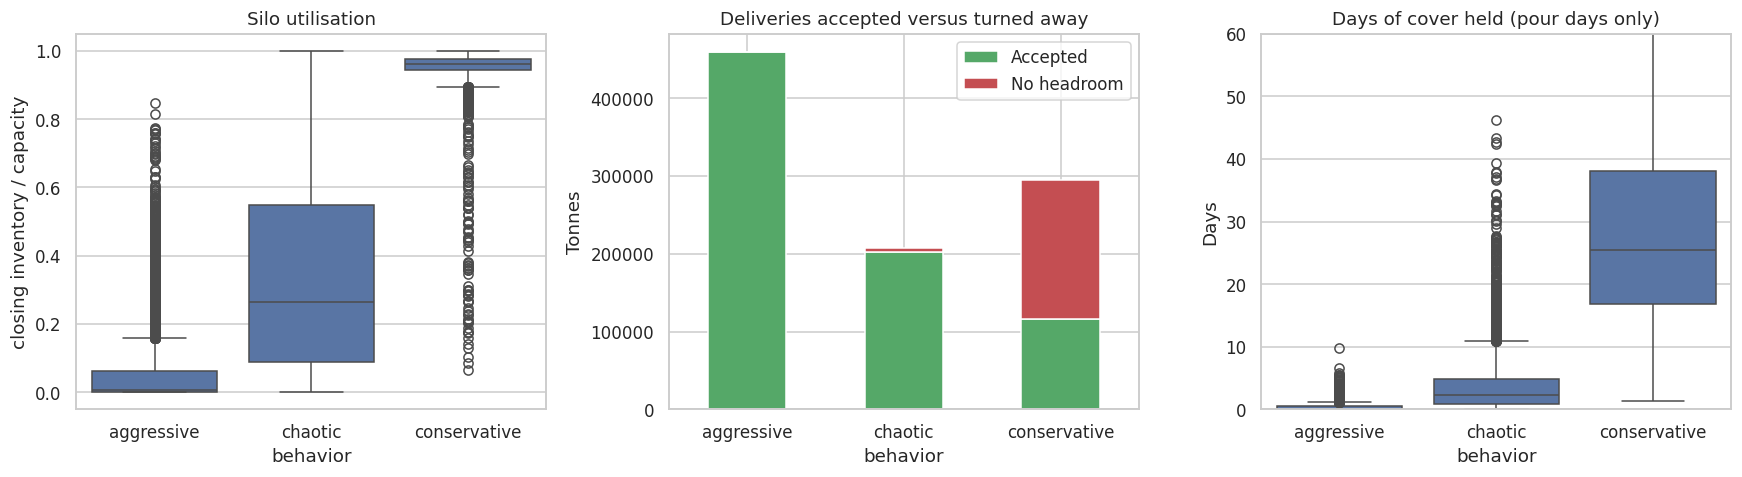

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.boxplot(data=panel, x="behavior", y="silo_utilisation", ax=axes[0], order=BEHAVIOUR_ORDER)
axes[0].set_title("Silo utilisation")
axes[0].set_ylabel("closing inventory / capacity")

panel.groupby("behavior")[["received_tonnes", "rejected_delivery_tonnes"]].sum().reindex(
    BEHAVIOUR_ORDER).plot(kind="bar", stacked=True, ax=axes[1], color=["#55a868", "#c44e52"])
axes[1].set_title("Deliveries accepted versus turned away")
axes[1].set_ylabel("Tonnes")
axes[1].legend(["Accepted", "No headroom"])

sns.boxplot(data=panel.dropna(subset=["cover_days"]), x="behavior", y="cover_days",
            ax=axes[2], order=BEHAVIOUR_ORDER)
axes[2].set_title("Days of cover held (pour days only)")
axes[2].set_ylabel("Days"); axes[2].set_ylim(0, 60)

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
save_fig("inventory_state")
plt.show()

In [38]:
pour_days = panel[panel["planned_pour_tonnes"] > 0]

baseline = pd.DataFrame({
    "metric": [
        "Pour readiness (planned-pour days met in full)",
        "Mean silo utilisation",
        "Deliveries turned away, % of offered",
        "Demand fill rate (tonnage)",
        "Days with an empty silo",
    ],
    "current baseline": [
        f"{100 * (1 - pour_days['was_constrained'].mean()):.1f}%",
        f"{100 * panel['silo_utilisation'].mean():.1f}%",
        f"{100 * panel['rejected_delivery_tonnes'].sum() / panel['deliveries_tonnes'].sum():.1f}%",
        f"{100 * panel['consumed_tonnes'].sum() / panel['planned_pour_tonnes'].sum():.1f}%",
        f"{100 * (panel['opening_inventory_tonnes'] < 1).mean():.1f}%",
    ],
    "improvement target": ["98%", "20% write-off reduction", "-30%", "-", "-"],
})
display(baseline)

,metric,current baseline,improvement target
0,Pour readiness (planned-pour days met in full),56.3%,98%
1,Mean silo utilisation,38.7%,20% write-off reduction
2,"Deliveries turned away, % of offered",19.2%,-30%
3,Demand fill rate (tonnage),77.3%,-
4,Days with an empty silo,25.4%,-


The inventory picture is bimodal in the same way the behaviours are: conservative
silos sit at 95% full and turn away 61% of arriving cement, aggressive silos sit
at 5% and are empty on 48.8% of days. Almost nothing sits in the healthy middle.

The baseline table is worth recording before any policy is designed, so that any
improvement claimed later is measured against a number fixed in advance:
**56.3% pour readiness, 38.7% mean utilisation, 19.2% of deliveries turned away,
77.3% demand fill rate.**

It also shows the two improvement targets live in different places. The 98%
pour-readiness target is entirely about the 14 aggressive sites; the write-off
target is entirely about the 9 conservative ones. They are opposite problems, and
moving supply from the second group to the first would improve both at once —
worth simulating explicitly.

## 15 — How the variables relate, and which relationships are illusory

A correlation matrix over every numeric column would be actively misleading here,
because the panel contains the target's own aliases and a set of end-of-day
outcomes alongside the genuine predictors. On one colour scale the strongest
cells turn out to be the ones that can never be used. This section separates
them.

In [39]:
target = panel["consumed_tonnes"]
leak_cols = [c for c in OUTCOME_COLS if c != "consumed_tonnes"]

excluded = (panel[leak_cols].select_dtypes("number").corrwith(target)
            .sort_values(key=abs, ascending=False).to_frame("corr with consumed_tonnes"))
excluded["reason it cannot be a feature"] = [
    {
        "y": "a copy of the target",
        "served_tonnes": "the target recomputed on the repaired ledger",
        "unmet_tonnes": "planned minus consumed — contains the target",
        "was_constrained": "records what happened on day t",
        "induced_shortfall": "records what happened on day t",
        "received_tonnes": "settled during day t",
        "rejected_delivery_tonnes": "settled during day t",
        "closing_inventory_tonnes": "end-of-day state, moves with the target",
        "silo_utilisation": "closing inventory divided by capacity",
        "cover_days": "null exactly when the target is zero (section 2)",
    }.get(c, "outcome of day t")
    for c in excluded.index
]
display(excluded.round(3))

,corr with consumed_tonnes,reason it cannot be a feature
y,1.000,a copy of the target
served_tonnes,0.994,the target recomputed on the repaired ledger
cover_days,-0.605,null exactly when the target is zero (section 2)
silo_utilisation,-0.486,closing inventory divided by capacity
received_tonnes,0.451,settled during day t
closing_inventory_tonnes,-0.429,"end-of-day state, moves with the target"
rejected_delivery_tonnes,-0.362,settled during day t
unmet_tonnes,-0.132,planned minus consumed — contains the target
induced_shortfall,0.124,records what happened on day t
was_constrained,0.063,records what happened on day t


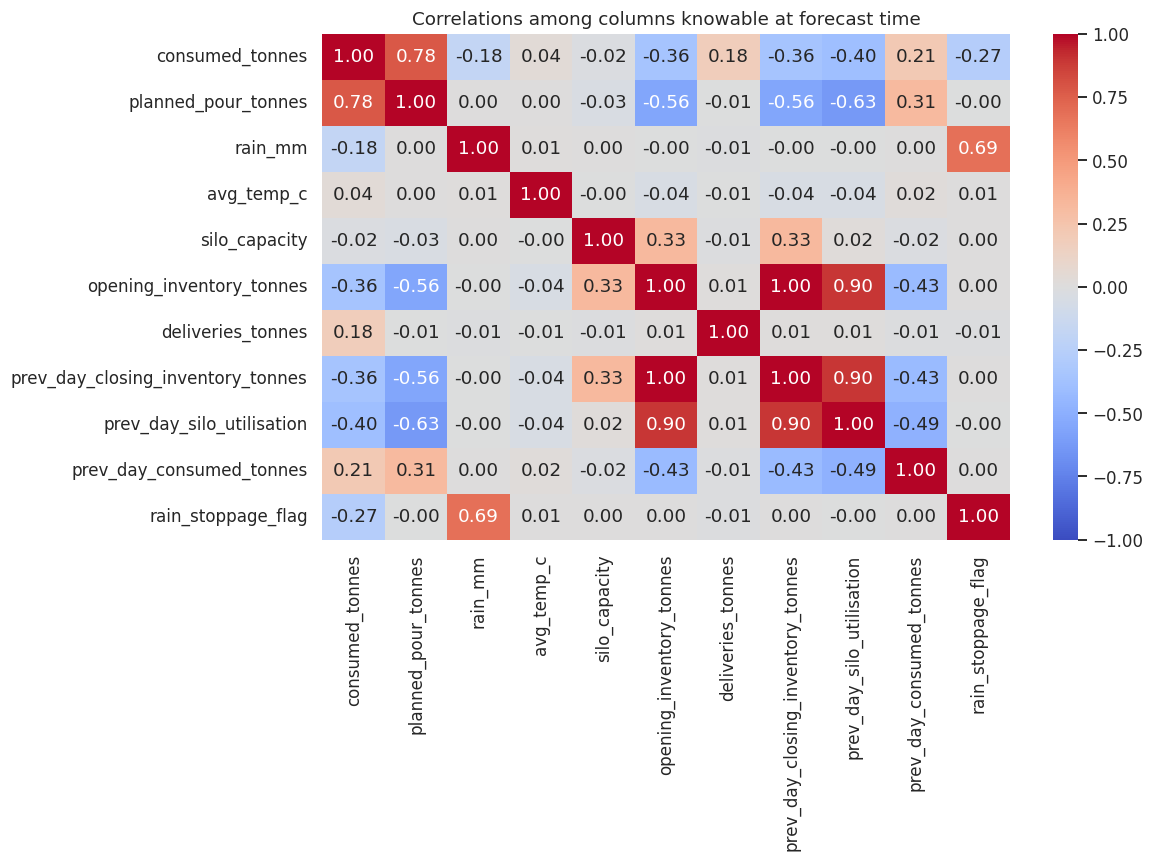

,corr with target
planned_pour_tonnes,0.781
prev_day_silo_utilisation,-0.397
prev_day_closing_inventory_tonnes,-0.359
opening_inventory_tonnes,-0.359
rain_stoppage_flag,-0.268
prev_day_consumed_tonnes,0.215
rain_mm,-0.180
deliveries_tonnes,0.177
avg_temp_c,0.035
silo_capacity,-0.021


In [40]:
panel_sorted = panel.sort_values(["site_id", "date"])
lagged = (panel_sorted.groupby("site_id")[
    ["closing_inventory_tonnes", "silo_utilisation", "consumed_tonnes"]]
    .shift(1).add_prefix("prev_day_"))

safe_frame = pd.concat([
    panel_sorted[["consumed_tonnes", "planned_pour_tonnes", "rain_mm", "avg_temp_c",
                  "silo_capacity", "opening_inventory_tonnes", "deliveries_tonnes"]],
    lagged,
    (panel_sorted["rain_mm"] > RAIN_STOPPAGE_MM).astype(int).rename("rain_stoppage_flag"),
], axis=1)

plt.figure(figsize=(11, 8))
sns.heatmap(safe_frame.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlations among columns knowable at forecast time")
plt.tight_layout()
save_fig("correlation_safe")
plt.show()

display(safe_frame.corr()["consumed_tonnes"].drop("consumed_tonnes")
        .sort_values(key=abs, ascending=False).round(3).to_frame("corr with target"))

In [41]:
# prev_day_consumed shows +0.215 above, which appears to contradict section 9.
# Pooling across sites lets a cross-sectional difference look like memory.
prev_day = panel_sorted.groupby("site_id")["consumed_tonnes"].shift(1)
site_mean = panel_sorted.groupby("site_id")["consumed_tonnes"].transform("mean")

print(f"corr(yesterday, today) pooled across all sites : {prev_day.corr(panel_sorted['consumed_tonnes']):+.3f}")
print(f"corr(yesterday, today) demeaned within site    : "
      f"{(prev_day - site_mean).corr(panel_sorted['consumed_tonnes'] - site_mean):+.3f}")
print()
print("The pooled figure is a site effect: busy sites are busy on consecutive days")
print("because they are busy sites, not because yesterday informs today.")

corr(yesterday, today) pooled across all sites : +0.215
corr(yesterday, today) demeaned within site    : -0.021

The pooled figure is a site effect: busy sites are busy on consecutive days
because they are busy sites, not because yesterday informs today.


**Only one genuine predictor stands out.** Among columns knowable in advance,
`planned_pour_tonnes` correlates at +0.78 and nothing else comes close. The
engineered `rain_stoppage_flag` reaches −0.27 — modest as a linear statistic
precisely because it is a switch affecting 4.9% of rows rather than a gradient
across all of them, which is why section 16 evaluates it by error instead.
`opening_inventory_tonnes` (−0.36) enters only through the censoring mechanism
described in section 13, not as a driver of demand.

**The apparent lag effect is not one.** `prev_day_consumed_tonnes` shows +0.215
pooled, which looks like it contradicts section 9. Demeaned within site it is
−0.021. The pooled figure is entirely a site fixed effect — a lag-1 feature here
would encode *which site this is*, which `behavior` already supplies without
warm-up rows or leakage surface. This is the most likely way for a lag block to
look valuable in cross-validation and contribute nothing in production.

**The excluded table is the more important half of this section.** `cover_days`
(−0.61), `silo_utilisation` (−0.49) and `closing_inventory_tonnes` (−0.43) are
the strongest correlations in the panel after planned pour, and all three are
*consequences* of the day's consumption rather than causes of it. A model given
them scores beautifully in validation and fails in production. That table is the
audit trail for the leakage review and should be carried into feature engineering
as an explicit deny-list.

## 16 — What generates the target

Sections 7, 12 and 13 each isolated one mechanism: a scheduled pour, a rainfall
cut-off, and a stock ceiling. Composed, they are not three features — they are an
account of how consumption arises. This section tests that directly.

In [42]:
def wape(actual, forecast):
    return np.abs(actual - forecast).sum() / np.abs(actual).sum()

demand_gate = panel["planned_pour_tonnes"] * (panel["rain_mm"] <= RAIN_STOPPAGE_MM)
stock_available = panel["opening_inventory_tonnes"] + panel["deliveries_tonnes"]
rule = np.minimum(demand_gate, stock_available)

actual = panel["consumed_tonnes"]
r2 = 1 - ((actual - rule) ** 2).sum() / ((actual - actual.mean()) ** 2).sum()

print("Rule:  consumed = min( planned_pour x [rain <= 15 mm] , opening_inventory + deliveries )")
print(f"  reproduced exactly (to 1e-6) : {np.isclose(rule, actual, atol=1e-6).mean():.1%} of rows")
print(f"  WAPE                         : {wape(actual, rule):.4f}")
print(f"  R-squared                    : {r2:.4f}")
print(f"  fitted parameters            : 0")

residual = actual - rule
misses = panel[residual.abs() > 0.01]
print(f"\n  rows not reproduced          : {len(misses):,}")
print(f"  of those, pour was cut short : {misses['was_constrained'].mean():.1%}")

Rule:  consumed = min( planned_pour x [rain <= 15 mm] , opening_inventory + deliveries )
  reproduced exactly (to 1e-6) : 83.9% of rows
  WAPE                         : 0.0426
  R-squared                    : 0.9600
  fitted parameters            : 0

  rows not reproduced          : 4,802
  of those, pour was cut short : 87.0%


,WAPE,RMSE,bias (t)
rule,,,
Global mean,0.605,16.846,-0.000
Per-site mean,0.468,14.777,-0.000
Planned pour alone,0.294,14.123,6.977
"Planned pour, gated on rain",0.247,11.833,5.460
"Planned pour, gated on rain, capped by stock",0.043,3.369,0.388


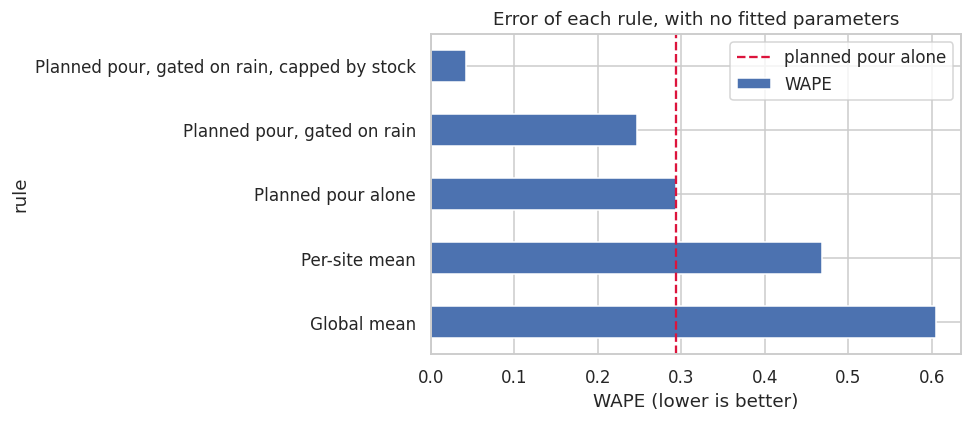

In [43]:
site_mean_forecast = panel.groupby("site_id")["consumed_tonnes"].transform("mean")

ladder = pd.DataFrame([
    ("Global mean", np.full(len(panel), actual.mean())),
    ("Per-site mean", site_mean_forecast),
    ("Planned pour alone", panel["planned_pour_tonnes"]),
    ("Planned pour, gated on rain", demand_gate),
    ("Planned pour, gated on rain, capped by stock", rule),
], columns=["rule", "values"])
ladder["WAPE"] = [wape(actual, v) for v in ladder["values"]]
ladder["RMSE"] = [np.sqrt(((actual - v) ** 2).mean()) for v in ladder["values"]]
ladder["bias (t)"] = [(v - actual).mean() for v in ladder["values"]]
ladder = ladder.drop(columns="values").set_index("rule").round(4)
display(ladder)

plt.figure(figsize=(9, 4))
ladder["WAPE"].plot(kind="barh", color="#4c72b0")
plt.axvline(ladder.loc["Planned pour alone", "WAPE"],
            color="crimson", linestyle="--", label="planned pour alone")
plt.title("Error of each rule, with no fitted parameters")
plt.xlabel("WAPE (lower is better)"); plt.legend()
plt.tight_layout()
save_fig("benchmark_ladder")
plt.show()

**Consumption is very nearly deterministic.**

| rule | WAPE | fitted parameters |
|---|---|---|
| Global mean | 60.5% | 1 |
| Per-site mean | 46.8% | 30 |
| Planned pour alone | 29.4% | 0 |
| Planned pour, gated on rain | 24.7% | 0 |
| **Planned pour, gated on rain, capped by stock** | **4.3%** | **0** |

`consumed = min(planned_pour × [rain ≤ 15 mm], opening_inventory + deliveries)`
reproduces the target exactly on 83.9% of site-days, with R² = 0.96 and WAPE
4.3%, without estimating anything. The rows it misses are 87% ones where the pour
was cut short, where the interaction with the ledger is imperfect.

This is the central fact about the dataset, and four things follow from it.

**The operation is a scheduling process, not a stochastic demand process.**
Cement gets poured when it is scheduled, unless it rains hard or the silo is
empty. Describing it any other way overstates the uncertainty involved.

**There is little room for a learned model to add value on these inputs.**
Modelling should be benchmarked against this rule rather than against a naive
mean. A gradient
boosting model reporting 12% WAPE would be a materially worse result presented as
a good one.

**The genuine forecasting question is about the schedule.** All the signal sits
in `planned_pour_tonnes`, which is set administratively. What is actually hard —
and actually useful — is projecting what the planned pour will be eight weeks
out, and attaching a probability to the rain gate.

**Demand forecasting and inventory simulation are one model, not two.** The stock
term is unknown beyond a one-day horizon; it is an *output* of the inventory
simulation. An 8-week forecast therefore has to roll the demand projection and
the inventory projection forward together, rather than producing a demand
forecast first and simulating inventory against it afterwards. That is an
architectural decision worth settling before the modelling code is written.

## 17 — Grain, splits and modelling readiness

Everything above describes the panel at site-day grain. The business orders
weekly and needs an 8-week outlook, so this section checks how the data behaves
when aggregated, and confirms the configured train / validation /
test split is workable.

In [44]:
daily_zero_share = (panel["consumed_tonnes"] == 0).mean()
weekly = panel.set_index("date").groupby("site_id")["consumed_tonnes"].resample("W").sum()
monthly = panel.set_index("date").groupby("site_id")["consumed_tonnes"].resample("ME").sum()

grain = pd.DataFrame({
    "grain": ["site-day", "site-week", "site-month"],
    "buckets": [len(panel), len(weekly), len(monthly)],
    "zero buckets": [int((panel["consumed_tonnes"] == 0).sum()), int((weekly == 0).sum()), int((monthly == 0).sum())],
    "zero %": [f"{daily_zero_share:.2%}", f"{(weekly == 0).mean():.2%}", f"{(monthly == 0).mean():.2%}"],
    "mean (t)": [panel["consumed_tonnes"].mean(), weekly.mean(), monthly.mean()],
    "CV": [
        panel["consumed_tonnes"].std() / panel["consumed_tonnes"].mean(),
        weekly.std() / weekly.mean(),
        monthly.std() / monthly.mean(),
    ],
    "MAPE usable": ["no — undefined on 12.2% of rows", "yes", "yes"],
})
display(grain.set_index("grain").round(3))

,buckets,zero buckets,zero %,mean (t),CV,MAPE usable
grain,,,,,,
site-day,32880,4003,12.17%,23.720,0.710,no — undefined on 12.2% of rows
site-week,4740,0,0.00%,164.542,0.415,yes
site-month,1080,0,0.00%,722.157,0.359,yes


In [45]:
splits = [
    ("train", None, settings.train_end),
    ("validation", settings.train_end, settings.val_end),
    ("test (touch once)", settings.val_end, None),
]
rows = []
for name, lo, hi in splits:
    mask = pd.Series(True, index=panel.index)
    if lo:
        mask &= panel["date"] > pd.Timestamp(lo)
    if hi:
        mask &= panel["date"] <= pd.Timestamp(hi)
    sub = panel[mask]
    rows.append({
        "split": name,
        "from": sub["date"].min().date(),
        "to": sub["date"].max().date(),
        "rows": len(sub),
        "% of panel": 100 * len(sub) / len(panel),
        "weeks": sub["date"].nunique() / 7,
        "mean consumed (t)": sub["consumed_tonnes"].mean(),
        "zero rows %": 100 * (sub["consumed_tonnes"] == 0).mean(),
    })
display(pd.DataFrame(rows).set_index("split").round(2))

print(f"Forecast horizon required: {settings.forecast_horizon_weeks} weeks")
print("Validation and test are each one quarter — enough for a single 8-week")
print("horizon plus a little margin, so rolling-origin backtesting for honest")
print("error bars has to run inside the training period.")

,from,to,rows,% of panel,weeks,mean consumed (t),zero rows %
split,,,,,,,
train,2022-01-01,2024-06-30,27360,83.210,130.290,23.790,12.130
validation,2024-07-01,2024-09-30,2760,8.390,13.140,23.400,11.990
test (touch once),2024-10-01,2024-12-31,2760,8.390,13.140,23.330,12.790


Forecast horizon required: 8 weeks
Validation and test are each one quarter — enough for a single 8-week
horizon plus a little margin, so rolling-origin backtesting for honest
error bars has to run inside the training period.


**Aggregation removes the zero problem entirely.** At site-day grain 12.2% of
buckets are zero and MAPE is undefined. At site-week grain **there are no zero
buckets at all** — 0 out of 4,740 — and the same holds monthly. Every site pours
something every week. Any accuracy target expressed as a percentage error should
therefore be agreed at weekly grain, where it is well defined, rather than daily,
where it is not. Weekly is also the grain the business orders
on, and aggregation drops the coefficient of variation from 0.75 to 0.41.

The configured split gives 83.2% train, 8.4% validation, 8.4% test, each block
contiguous in time with the final quarter held back. Since demand has no trend
and no seasonality, the three periods are near-identical in distribution — which
means a time-based split costs nothing in representativeness, but also that a
good test score demonstrates less than it usually would.

## 18 — Findings and decisions

The table below collects every finding that changes what gets built, with the
evidence for it, and the decision it supports.

In [46]:
findings = pd.DataFrame([
    ("Site heterogeneity",
     "site 23.1% of variance, behaviour 23.0%, region 1.5%, cement type 0.0%; residual site effect after behaviour 0.05%",
     "One global pooled model with `behavior` as a categorical. Not 30 per-site models. Drop `region`."),
    ("Temporal memory",
     "site autocorrelation <= |0.02| at lags 1/7/14/28, no site above |r|=0.10; ACF/PACF inside the white-noise band",
     "Cut the lag and rolling-statistic feature block. Fit SARIMAX once as a documented baseline only."),
    ("Calendar seasonality",
     "fixed weekday effect explains 0.0% of variance, month 0.1%; STL seasonal strength only 0.28",
     "Drop calendar features. No seasonal ARIMA terms."),
    ("Weather",
     "step change at 15.0 mm: consumption 24.75 -> 3.95 t, zero days 9.3% -> 67.9%; r = +0.005 below the threshold; rain has no seasonality",
     "Add binary `rain_stoppage`. Drop raw rain_mm and avg_temp_c. At long horizons model it as P(rain <= 15) = 4.9%."),
    ("Censored target",
     "39.7% of rows cut short; aggressive sites 65.0% cut short, 195,289 t unmet (85% of the total), 5% utilisation vs conservative 14.3% / 3,476 t / 95%",
     "Fit planned_pour_tonnes as the demand target. Report accuracy on consumed_tonnes plus fill rate."),
    ("Leakage",
     "cover_days is null exactly when the target is zero; silo_utilisation, closing_inventory and unmet_tonnes are day-t outcomes; pooled lag-1 r=+0.215 is a site effect (-0.021 within site)",
     "Use the section 3 availability table as an allow-list. Lagged state only, shifted within site."),
    ("Metric set and grain",
     "12.2% zero rows daily, structurally explained; zero zero-buckets at weekly or monthly grain",
     "WAPE and MASE primary. MAPE at weekly grain, where it is fully defined. Two-stage hurdle structure."),
    ("Benchmark",
     "min(planned x rain gate, stock) reaches WAPE 4.3%, R2 0.96, zero fitted parameters",
     "Benchmark any model against this rule, not the naive mean. Reframe the problem as forecasting planned pour."),
    ("Architecture",
     "the stock term is an output of the inventory simulation and is unknown beyond h=1",
     "Roll the demand forecast and the inventory projection forward jointly. Settle before the modelling code is written."),
    ("Counterfactual",
     "deliveries arrive at a flat ~30 t/day on ~98% of days regardless of stock or schedule; no site responds to its inventory position",
     "Current practice is blind ordering, not reactive ordering. Describe the baseline honestly when reporting the improvement."),
], columns=["finding", "evidence", "decision"])

pd.set_option("display.max_colwidth", None)
display(findings.set_index("finding"))

,evidence,decision
finding,,
Site heterogeneity,"site 23.1% of variance, behaviour 23.0%, region 1.5%, cement type 0.0%; residual site effect after behaviour 0.05%",One global pooled model with `behavior` as a categorical. Not 30 per-site models. Drop `region`.
Temporal memory,"site autocorrelation <= |0.02| at lags 1/7/14/28, no site above |r|=0.10; ACF/PACF inside the white-noise band",Cut the lag and rolling-statistic feature block. Fit SARIMAX once as a documented baseline only.
Calendar seasonality,"fixed weekday effect explains 0.0% of variance, month 0.1%; STL seasonal strength only 0.28",Drop calendar features. No seasonal ARIMA terms.
Weather,"step change at 15.0 mm: consumption 24.75 -> 3.95 t, zero days 9.3% -> 67.9%; r = +0.005 below the threshold; rain has no seasonality",Add binary `rain_stoppage`. Drop raw rain_mm and avg_temp_c. At long horizons model it as P(rain <= 15) = 4.9%.
Censored target,"39.7% of rows cut short; aggressive sites 65.0% cut short, 195,289 t unmet (85% of the total), 5% utilisation vs conservative 14.3% / 3,476 t / 95%",Fit planned_pour_tonnes as the demand target. Report accuracy on consumed_tonnes plus fill rate.
Leakage,"cover_days is null exactly when the target is zero; silo_utilisation, closing_inventory and unmet_tonnes are day-t outcomes; pooled lag-1 r=+0.215 is a site effect (-0.021 within site)","Use the section 3 availability table as an allow-list. Lagged state only, shifted within site."
Metric set and grain,"12.2% zero rows daily, structurally explained; zero zero-buckets at weekly or monthly grain","WAPE and MASE primary. MAPE at weekly grain, where it is fully defined. Two-stage hurdle structure."
Benchmark,"min(planned x rain gate, stock) reaches WAPE 4.3%, R2 0.96, zero fitted parameters","Benchmark any model against this rule, not the naive mean. Reframe the problem as forecasting planned pour."
Architecture,the stock term is an output of the inventory simulation and is unknown beyond h=1,Roll the demand forecast and the inventory projection forward jointly. Settle before the modelling code is written.


### What the data says, in one paragraph

MIG runs 30 construction sites that fall into three groups defined by how much
concrete they schedule against a cement supply that arrives at a flat rate
regardless of need. Demand has no trend, no calendar seasonality and no
day-to-day memory; it is set by a schedule, cancelled by rain above 15 mm, and
truncated when the silo is empty. Those three mechanisms together reproduce
recorded consumption to within 4.3% error with nothing fitted. The sites that
schedule the most work have the thinnest cover and lose a third of their planned
pours, while the sites that schedule the least sit permanently full and turn away
61% of their deliveries — silo capacity having been assigned with no reference to
throughput. The forecasting problem is therefore narrow and the inventory problem
is wide, and the value of the project lies almost entirely in the second.

### What this notebook establishes

- Site heterogeneity quantified, and shown to be carried entirely by `behavior` (section 10)
- No temporal memory at any lag or grain, so the lag feature block can be cut (section 9)
- The 15 mm rainfall threshold identified and specified as a flag (section 12)
- The planned-versus-actual gap quantified by behaviour and stock position (section 13)
- A leakage allow-list drafted for feature engineering to enforce (sections 3 and 15)
- The operational baseline recorded, for any new ordering policy to be measured against (section 14)
- A benchmark that modelling has to clear (section 16)

### Handover to feature engineering

The feature set this notebook supports is deliberately short:

`planned_pour_tonnes`, `rain_stoppage` (rain_mm > 15), `behavior`,
`silo_capacity`, lagged inventory state (shifted within site), and `cement_type`
carried for inventory allocation rather than prediction.

No target lags, no rolling statistics, no calendar terms, no raw same-day
inventory, no region. Every one of those omissions is justified by a numbered
section above, which is what makes a deliberately thin feature set defensible to
a reader expecting a conventional time-series pipeline.